# Analyse des tendances de recherche en ligne

## Introduction

Les recherches sur Internet permettent de mieux comprendre les centres d’intérêt des internautes. Dans le domaine de l’intelligence artificielle et des technologies, elles permettent d’observer l’apparition de nouveaux sujets, la stabilité de certains thèmes et l’influence de l’actualité.

L’objectif de ce projet est d’analyser l’évolution de plusieurs mots-clés liés à l’IA et aux technologies, de les comparer, et de les regrouper selon leurs comportements dans le temps.

Ce projet vise donc à exploiter les données de Google Trends afin d’analyser, comparer et regrouper des sujets liés à l’intelligence artificielle selon leurs dynamiques temporelles.



## Méthodologie

Les données ont été collectées avec Google Trends pour la France entre 2020 et 2025, à l’aide de la bibliothèque `pytrends`.

Après nettoyage et préparation des données, plusieurs analyses ont été réalisées :
- statistiques descriptives  
- visualisations des tendances  
- corrélations entre mots-clés  
- clustering pour regrouper les mots-clés selon leur évolution  

Il est important de noter que les données de Google Trends sont normalisées (entre 0 et 100), ce qui signifie qu’elles sont relatives et non absolues. Les comparaisons doivent donc être interprétées avec prudence.



# PARTIE 1: Pipeline de traitement des données

In [87]:
!pip install pytrends

## 1. Imports (code)

In [88]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pytrends.request import TrendReq
from pytrends.exceptions import TooManyRequestsError
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

### Bibliothèques utilisées

- **`os`** : interaction avec le système (fichiers, chemins).
- **`time`** : gestion du temps (délais, timestamps).
- **`numpy` (`np`)** : calcul scientifique et manipulation de tableaux.
- **`pandas` (`pd`)** : analyse et manipulation de données tabulaires.
- **`matplotlib.pyplot` (`plt`)** : visualisation de données (graphiques).
- **`seaborn` (`sns`)** : visualisations statistiques avancées basées sur matplotlib.

### Données et tendances
- **`TrendReq` (pytrends)** : récupération des données Google Trends.

### Machine Learning
- **`StandardScaler`** : normalisation des données (centrage-réduction).
- **`KMeans`** : algorithme de clustering non supervisé.

In [89]:
# Paramètres généraux
GEO = "FR"
TIMEFRAME = "2020-01-01 2025-12-31"

# Liste de mots-clés
keywords = [
    "intelligence artificielle",
    "ia",
    "chatgpt",
    "openai",
    "machine learning",
    "deep learning",
    "data science",
    "big data",
    "algorithme",
    "robot",
    "automatisation",
    "cybersécurité",
    "cloud computing",
    "serveur",
    "gpu",
    "nvidia",
    "bitcoin",
    "blockchain",
    "réalité virtuelle",
    "metaverse"
]

# Dossiers
RAW_DIR = "../data/raw"
PROCESSED_DIR = "../data/processed"
FIG_DIR = "../figures"

import os
os.makedirs(RAW_DIR, exist_ok=True)
os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

print("Paramètres OK")

Paramètres OK


### 2. Paramètres généraux

- **`GEO`** : zone géographique étudiée (`FR` pour la France).
- **`TIMEFRAME`** : période d’analyse des données (de 2020 à 2025).

### a) Mots-clés analysés

Liste de termes liés aux technologies et au numérique :
- Intelligence artificielle, machine learning, deep learning  
- Outils et acteurs (ChatGPT, OpenAI, Nvidia)  
- Concepts data (data science, big data, algorithme)  
- Infrastructures (cloud computing, serveur, GPU)  
- Technologies émergentes (blockchain, metaverse, réalité virtuelle)  
- Sécurité et automatisation (cybersécurité, robot, automatisation)

### b) Organisation des données

- **`RAW_DIR`** : stockage des données brutes  
- **`PROCESSED_DIR`** : données nettoyées et transformées  
- **`FIG_DIR`** : visualisations et graphiques  

Les dossiers sont créés automatiquement si inexistants (`os.makedirs` avec `exist_ok=True`).

### c) Validation

- Affichage d’un message confirmant que les paramètres sont correctement initialisés.

In [153]:
def recup_tendance(motcle, timeframe=TIMEFRAME, geo=GEO, retries=3, backoff=5):
    pytrends = TrendReq(hl="fr-FR", tz=360)
    attempt = 0

    while True:
        try:
            pytrends.build_payload(
                kw_list=[motcle],
                cat=0,
                timeframe=timeframe,
                geo=geo,
                gprop=""
            )

            df = pytrends.interest_over_time()
            break

        except TooManyRequestsError:
            attempt += 1
            if attempt >= retries:
                raise
            wait = backoff * (2 ** (attempt - 1))
            print(f"Trop de requêtes Google Trends ({attempt}/{retries}), attente {wait}s...")
            time.sleep(wait)

    if df.empty:
        return pd.DataFrame()

    df = df.reset_index()

    if "isPartial" in df.columns:
        df = df.drop(columns=["isPartial"])

    df = df.rename(columns={motcle: "valeur"})
    df["mot_cle"] = motcle

    return df

### 2.1 Fonction `recup_tendance`

Récupère l’évolution temporelle de l’intérêt pour un mot-clé via Google Trends.

### a) Paramètres
- **`motcle`** : terme à analyser  
- **`timeframe`** : période d’étude (par défaut définie globalement)  
- **`geo`** : zone géographique (ex : `FR`)  

### b) Fonctionnement
1. Initialise une connexion à Google Trends via `TrendReq`.
2. Configure la requête avec :
   - le mot-clé
   - la période
   - la zone géographique
3. Récupère les données d’intérêt dans le temps (`interest_over_time`).

### c) Nettoyage des données
- Retourne un DataFrame vide si aucune donnée.
- Réinitialise l’index (date → colonne).
- Supprime la colonne `isPartial` si présente.
- Renomme la colonne du mot-clé en **`valeur`**.
- Ajoute une colonne **`mot_cle`** pour identifier le terme.

### d) Sortie
- Un DataFrame structuré avec :
  - la date
  - la valeur d’intérêt
  - le mot-clé associé

In [91]:
time.sleep(5)

In [92]:
# Test de la fonction recup_tendance

print("🔍 Test de la fonction recup_tendance avec 'chatgpt'...")

test_df = recup_tendance("chatgpt")

# Vérifications
if test_df.empty:
    print("Aucune donnée récupérée")
else:
    print("✅ Données récupérées avec succès")
    print("Dimensions :", test_df.shape)
    display(test_df.head())

🔍 Test de la fonction recup_tendance avec 'chatgpt'...
✅ Données récupérées avec succès
Dimensions : (72, 3)


,date,valeur,mot_cle
0,2020-01-01,0,chatgpt
1,2020-02-01,0,chatgpt
2,2020-03-01,0,chatgpt
3,2020-04-01,0,chatgpt
4,2020-05-01,0,chatgpt


### 2.2 Test de la fonction `recup_tendance`

Ce bloc vérifie le bon fonctionnement de la fonction avec le mot-clé **"chatgpt"**.

### a) Étapes
- Appel de la fonction :
  - `recup_tendance("chatgpt")`
- Stockage du résultat dans **`test_df`**

### b) Vérifications
- **`test_df.shape`** : affiche les dimensions du DataFrame (lignes, colonnes)
- **`test_df.head()`** : affiche les premières lignes pour inspection rapide

### c) Objectif
S’assurer que :
- des données sont bien récupérées
- la structure du DataFrame est correcte
- les colonnes attendues (`date`, `valeur`, `mot_cle`) sont présentes

In [93]:
all_data = []

for mot in keywords:
    try:
        print(f"Récupération : {mot}")
        df_temp = recup_tendance(mot)

        if not df_temp.empty:
            all_data.append(df_temp)
            print(f"  -> {df_temp.shape[0]} lignes récupérées")
        else:
            print(f"  -> aucune donnée")

        time.sleep(2)

    except Exception as e:
        print(f"Erreur pour {mot} : {e}")

Récupération : intelligence artificielle
  -> 72 lignes récupérées
Récupération : ia
  -> 72 lignes récupérées
Récupération : chatgpt
  -> 72 lignes récupérées
Récupération : openai
  -> 72 lignes récupérées
Récupération : machine learning
  -> 72 lignes récupérées
Récupération : deep learning
  -> 72 lignes récupérées
Récupération : data science
  -> 72 lignes récupérées
Récupération : big data
  -> 72 lignes récupérées
Récupération : algorithme
  -> 72 lignes récupérées
Récupération : robot
  -> 72 lignes récupérées
Récupération : automatisation
  -> 72 lignes récupérées
Récupération : cybersécurité
  -> 72 lignes récupérées
Récupération : cloud computing
  -> 72 lignes récupérées
Récupération : serveur
  -> 72 lignes récupérées
Récupération : gpu
  -> 72 lignes récupérées
Récupération : nvidia
  -> 72 lignes récupérées
Récupération : bitcoin
  -> 72 lignes récupérées
Récupération : blockchain
  -> 72 lignes récupérées
Récupération : réalité virtuelle
  -> 72 lignes récupérées
Récupé

### 3. Collecte des données pour tous les mots-clés

Ce bloc parcourt la liste des mots-clés et récupère leurs tendances Google Trends.

### a) Fonctionnement
- Initialise une liste vide **`all_data`** pour stocker les résultats.
- Pour chaque mot-clé dans **`keywords`** :
  1. Affiche le mot en cours de traitement.
  2. Appelle la fonction `recup_tendance(mot)`.
  3. Vérifie si des données ont été récupérées :
     - Si oui : ajoute le DataFrame à `all_data` et affiche le nombre de lignes.
     - Sinon : indique qu’aucune donnée n’est disponible.

### b) Gestion du rythme
- Pause de **2 secondes** entre chaque requête (`time.sleep(2)`)  
  → évite le blocage par Google Trends.

### c) Gestion des erreurs
- Utilise un bloc `try/except` :
  - Capture les erreurs pour un mot-clé donné
  - Continue l’exécution sans interrompre la boucle

### d) Résultat
- **`all_data`** contient une liste de DataFrames exploitables pour une consolidation ultérieure.

In [94]:
df_long = pd.concat(all_data, ignore_index=True)

print(df_long.shape)
df_long.head()

(1440, 3)


,date,valeur,mot_cle
0,2020-01-01,13,intelligence artificielle
1,2020-02-01,14,intelligence artificielle
2,2020-03-01,12,intelligence artificielle
3,2020-04-01,13,intelligence artificielle
4,2020-05-01,11,intelligence artificielle


### 4. Fusion des données

Ce bloc regroupe toutes les données collectées en un seul DataFrame.

### a) Étapes
- **`pd.concat(all_data, ignore_index=True)`** :
  - Fusionne tous les DataFrames contenus dans `all_data`
  - Réinitialise l’index pour obtenir une numérotation continue

### b) Vérifications
- **`df_long.shape`** : affiche la taille du DataFrame final (lignes, colonnes)
- **`df_long.head()`** : aperçu des premières lignes

### c) Résultat
- **`df_long`** contient l’ensemble des données de tendances
- Format “long” :
  - une ligne = une date + un mot-clé + une valeur
```

In [95]:
raw_path = os.path.join(RAW_DIR, "trends_brut_long.csv")

df_long.to_csv(raw_path, index=False, encoding="utf-8-sig")

print("Fichier brut sauvegardé :", raw_path)

Fichier brut sauvegardé : ../data/raw/trends_brut_long.csv


### 5. Sauvegarde des données brutes

Ce bloc enregistre le DataFrame consolidé dans un fichier CSV.

### a) Étapes
- **`os.path.join(RAW_DIR, "trends_brut_long.csv")`** :
  - Construit le chemin du fichier de sortie dans le dossier des données brutes

- **`df_long.to_csv(...)`** :
  - Exporte le DataFrame en CSV
  - `index=False` : ne sauvegarde pas l’index
  - `encoding="utf-8-sig"` : assure la compatibilité (notamment avec Excel)

### b) Résultat
- Fichier créé : **`trends_brut_long.csv`**
- Contient l’ensemble des données de tendances au format long

### c) Confirmation
- Affiche le chemin du fichier sauvegardé pour vérification

In [96]:
print(df_long.shape)
print(df_long.columns)
print(df_long.dtypes)

df_long.head()

(1440, 3)
Index(['date', 'valeur', 'mot_cle'], dtype='object')
date       datetime64[ns]
valeur              int64
mot_cle            object
dtype: object


,date,valeur,mot_cle
0,2020-01-01,13,intelligence artificielle
1,2020-02-01,14,intelligence artificielle
2,2020-03-01,12,intelligence artificielle
3,2020-04-01,13,intelligence artificielle
4,2020-05-01,11,intelligence artificielle


In [97]:
df_long.info()
print(df_long.isnull().sum())
print("Doublons :", df_long.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   date     1440 non-null   datetime64[ns]
 1   valeur   1440 non-null   int64         
 2   mot_cle  1440 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 33.9+ KB
date       0
valeur     0
mot_cle    0
dtype: int64
Doublons : 0


### 6. Analyse exploratoire et qualité des données

Cette étape combine une inspection rapide de la structure et un diagnostic de qualité du DataFrame **`df_long`**.

### a) Structure des données
- **`df_long.shape`** : dimensions (lignes, colonnes)
- **`df_long.columns`** : noms des variables
- **`df_long.dtypes`** : types de données
- **`df_long.head()`** : aperçu des premières observations

### b)  Qualité des données
- **`df_long.info()`** :
  - résumé global (types, valeurs non nulles, mémoire)
- **`df_long.isnull().sum()`** :
  - détection des valeurs manquantes par colonne
- **`df_long.duplicated().sum()`** :
  - identification des doublons

### c)  Objectif
Vérifier que :
- la structure est cohérente
- les types sont corrects
- les données sont complètes et sans duplication

=> pour préparer les étapes de nettoyage et d’analyse.

In [98]:
df_long["date"] = pd.to_datetime(df_long["date"])
df_long["mot_cle"] = df_long["mot_cle"].str.strip().str.lower()

df_long = df_long.dropna(subset=["date", "valeur", "mot_cle"])
df_long = df_long.drop_duplicates()
df_long = df_long.sort_values(["mot_cle", "date"]).reset_index(drop=True)

df_long.head()

,date,valeur,mot_cle
0,2020-01-01,86,algorithme
1,2020-02-01,93,algorithme
2,2020-03-01,94,algorithme
3,2020-04-01,78,algorithme
4,2020-05-01,79,algorithme


### 7. Nettoyage et préparation des données

Cette étape standardise et fiabilise le DataFrame **`df_long`** avant analyse.

### a) Transformations
- **Conversion des dates** :
  - `date` → format datetime pour faciliter les analyses temporelles

- **Normalisation des mots-clés** :
  - suppression des espaces inutiles (`strip`)
  - mise en minuscules (`lower`)
  → évite les doublons liés à la casse ou aux espaces

### b) Nettoyage
- Suppression des lignes avec valeurs manquantes sur :
  - `date`, `valeur`, `mot_cle`
- Suppression des doublons

### c) Organisation
- Tri des données par **mot-clé** puis **date**
- Réinitialisation de l’index

### d) Vérification
- **`df_long.head()`** : aperçu après nettoyage

### e) Objectif
Obtenir un dataset propre, homogène et prêt pour l’analyse ou la modélisation.

In [99]:
clean_long_path = os.path.join(PROCESSED_DIR, "trends_clean_long.csv")
df_long.to_csv(clean_long_path, index=False, encoding="utf-8-sig")

print("Fichier propre sauvegardé :", clean_long_path)

Fichier propre sauvegardé : ../data/processed/trends_clean_long.csv


In [100]:
df_wide = df_long.pivot(index="date", columns="mot_cle", values="valeur")
df_wide = df_wide.sort_index()

print(df_wide.shape)
df_wide.head()

(72, 20)


mot_cle,algorithme,automatisation,big data,bitcoin,blockchain,chatgpt,cloud computing,cybersécurité,data science,deep learning,gpu,ia,intelligence artificielle,machine learning,metaverse,nvidia,openai,robot,réalité virtuelle,serveur
date,,,,,,,,,,,,,,,,,,,,
2020-01-01,86,45,90,19,54,0,32,8,28,40,19,4,13,35,0,23,0,61,92,67
2020-02-01,93,41,95,23,43,0,32,7,28,39,18,4,14,37,0,23,0,53,100,77
2020-03-01,94,37,81,42,34,0,29,6,23,34,20,6,12,32,0,25,0,53,65,94
2020-04-01,78,35,74,30,37,0,27,5,27,34,24,5,13,35,0,29,0,87,58,100
2020-05-01,79,34,85,33,35,0,27,6,24,33,26,5,11,34,0,28,0,93,60,88


### 7) Transformation en format large (wide)

Cette étape restructure les données pour faciliter l’analyse comparative entre mots-clés.

### a) Transformation
- **`pivot(index="date", columns="mot_cle", values="valeur")`** :
  - chaque **ligne** représente une date
  - chaque **colonne** correspond à un mot-clé
  - les **valeurs** indiquent l’intérêt (Google Trends)

- **Tri des dates** :
  - `sort_index()` assure un ordre chronologique

### b) Vérifications
- **`df_wide.shape`** : dimensions du nouveau DataFrame
- **`df_wide.head()`** : aperçu des premières lignes

### c) Résultat
- Format “large” :
  - une ligne = une date
  - une colonne = un mot-clé
- Idéal pour :
  - visualisations multi-séries
  - corrélations
  - modèles de machine learning

### d) Objectif
Passer d’un format long à un format exploitable pour analyses comparatives et algorithmes.

In [101]:
df_wide = df_wide.interpolate(method="linear", axis=0)
df_wide = df_wide.bfill().ffill()

print(df_wide.isnull().sum())
df_wide.head()

mot_cle
algorithme                   0
automatisation               0
big data                     0
bitcoin                      0
blockchain                   0
chatgpt                      0
cloud computing              0
cybersécurité                0
data science                 0
deep learning                0
gpu                          0
ia                           0
intelligence artificielle    0
machine learning             0
metaverse                    0
nvidia                       0
openai                       0
robot                        0
réalité virtuelle            0
serveur                      0
dtype: int64


mot_cle,algorithme,automatisation,big data,bitcoin,blockchain,chatgpt,cloud computing,cybersécurité,data science,deep learning,gpu,ia,intelligence artificielle,machine learning,metaverse,nvidia,openai,robot,réalité virtuelle,serveur
date,,,,,,,,,,,,,,,,,,,,
2020-01-01,86,45,90,19,54,0,32,8,28,40,19,4,13,35,0,23,0,61,92,67
2020-02-01,93,41,95,23,43,0,32,7,28,39,18,4,14,37,0,23,0,53,100,77
2020-03-01,94,37,81,42,34,0,29,6,23,34,20,6,12,32,0,25,0,53,65,94
2020-04-01,78,35,74,30,37,0,27,5,27,34,24,5,13,35,0,29,0,87,58,100
2020-05-01,79,34,85,33,35,0,27,6,24,33,26,5,11,34,0,28,0,93,60,88


### 8. Gestion des valeurs manquantes

Cette étape traite les éventuels trous dans les séries temporelles.

### a) Méthodes appliquées
- **Interpolation linéaire** :
  - `interpolate(method="linear", axis=0)`
  - estime les valeurs manquantes en fonction des points voisins

- **Remplissage complémentaire** :
  - `bfill()` : remplit vers l’arrière (valeurs suivantes)
  - `ffill()` : remplit vers l’avant (valeurs précédentes)

### b) Vérifications
- **`df_wide.isnull().sum()`** :
  - nombre de valeurs manquantes restantes par colonne
- **`df_wide.head()`** :
  - aperçu après traitement

### c) Résultat
- Séries temporelles complètes et continues
- Plus de valeurs nulles (dans la majorité des cas)

### d) Objectif
Préparer des données exploitables pour :
- visualisation
- calculs statistiques
- modèles de machine learning
```

In [102]:
wide_path = os.path.join(PROCESSED_DIR, "trends_clean_wide.csv")
df_wide.to_csv(wide_path, encoding="utf-8-sig")

print("Fichier wide sauvegardé :", wide_path)

Fichier wide sauvegardé : ../data/processed/trends_clean_wide.csv


### 9. Traitement des valeurs manquantes

Cette étape complète les séries temporelles en comblant les valeurs absentes.

### a) Méthodes utilisées
- **Interpolation linéaire** :
  - estime les valeurs manquantes entre deux points connus

- **Remplissage des bords** :
  - `bfill()` : remplit avec la valeur suivante
  - `ffill()` : remplit avec la valeur précédente

### b) Contrôle
- **`df_wide.isnull().sum()`** :
  - vérifie qu’il ne reste plus de valeurs manquantes
- **`df_wide.head()`** :
  - aperçu du DataFrame final

### c) Objectif
Obtenir des séries complètes, sans discontinuité, prêtes pour l’analyse et la modélisation.

In [103]:
stats_df = df_long.groupby("mot_cle")["valeur"].agg(
    moyenne="mean",
    mediane="median",
    minimum="min",
    maximum="max",
    ecart_type="std"
).reset_index()

stats_df["amplitude"] = stats_df["maximum"] - stats_df["minimum"]
stats_df = stats_df.sort_values("moyenne", ascending=False).reset_index(drop=True)

stats_df.head(10)

,mot_cle,moyenne,mediane,minimum,maximum,ecart_type,amplitude
0,serveur,75.291667,73.0,65,100,7.417979,35
1,algorithme,70.208333,75.0,29,100,18.240906,71
2,robot,66.055556,63.0,47,100,12.437890,53
3,réalité virtuelle,63.125000,61.0,38,100,14.249228,62
4,automatisation,59.611111,59.0,32,100,16.762261,68
5,big data,59.472222,57.5,28,100,18.586662,72
6,blockchain,54.277778,50.0,30,100,16.954971,70
7,bitcoin,43.902778,41.5,17,100,18.797782,83
8,machine learning,38.527778,36.5,20,100,12.062014,80
9,deep learning,37.847222,35.5,22,100,11.508307,78


### 9. Statistiques descriptives par mot-clé

Cette étape calcule des indicateurs clés pour chaque mot-clé afin de comparer leur popularité.

### a) Calculs effectués
- Regroupement par **`mot_cle`**
- Agrégation des métriques sur **`valeur`** :
  - **moyenne** : niveau d’intérêt moyen  
  - **médiane** : valeur centrale  
  - **minimum / maximum** : bornes observées  
  - **écart-type** : variabilité (dispersion)

### b) Indicateur נוסף
- **`amplitude`** :
  - différence entre maximum et minimum
  - mesure l’ampleur des variations

### c) Organisation
- Tri décroissant par **moyenne**
- Réinitialisation de l’index

### d) Résultat
- **`stats_df.head(10)`** :
  - top 10 des mots-clés les plus populaires en moyenne

### c) Objectif
Comparer :
- le niveau global d’intérêt
- la stabilité ou volatilité des tendances
- les mots-clés dominants

In [104]:
evolution_rows = []

for col in df_wide.columns:
    serie = df_wide[col].dropna()

    debut = serie.iloc[:8].mean()
    fin = serie.iloc[-8:].mean()
    variation_absolue = fin - debut

    if debut != 0:
        variation_relative = (fin - debut) / debut
    else:
        variation_relative = np.nan

    evolution_rows.append({
        "mot_cle": col,
        "moyenne_debut": debut,
        "moyenne_fin": fin,
        "variation_absolue": variation_absolue,
        "variation_relative": variation_relative
    })

evolution_df = pd.DataFrame(evolution_rows)
evolution_df.head()

,mot_cle,moyenne_debut,moyenne_fin,variation_absolue,variation_relative
0,algorithme,73.250,49.875,-23.375,-0.319113
1,automatisation,37.875,83.250,45.375,1.198020
2,big data,76.750,52.625,-24.125,-0.314332
3,bitcoin,26.000,45.625,19.625,0.754808
4,blockchain,40.125,61.375,21.250,0.529595


### 10. Analyse de l’évolution des tendances

Cette étape mesure l’évolution de chaque mot-clé entre le début et la fin de la période.

### a) Méthode
- Parcourt chaque colonne (mot-clé) du DataFrame **`df_wide`**
- Pour chaque série temporelle :
  - **Début** : moyenne des 8 premières valeurs
  - **Fin** : moyenne des 8 dernières valeurs

### b) Indicateurs calculés
- **`moyenne_debut`** : niveau initial moyen  
- **`moyenne_fin`** : niveau final moyen  
- **`variation_absolue`** :
  - différence entre fin et début  
- **`variation_relative`** :
  - évolution en pourcentage  
  - calculée uniquement si la valeur initiale ≠ 0

### c) Construction du résultat
- Stockage des résultats dans une liste de dictionnaires
- Conversion en DataFrame **`evolution_df`**

### d) Vérification
- **`evolution_df.head()`** : aperçu des premières lignes

### e) Objectif
Identifier :
- les mots-clés en forte croissance
- ceux en déclin
- les dynamiques globales sur la période

In [105]:
stats_df = stats_df.merge(evolution_df, on="mot_cle", how="left")

stats_df["rang_popularite"] = stats_df["moyenne"].rank(ascending=False, method="dense")
stats_df["rang_volatilite"] = stats_df["ecart_type"].rank(ascending=False, method="dense")

stats_df.head(10)

,mot_cle,moyenne,mediane,minimum,maximum,ecart_type,amplitude,moyenne_debut,moyenne_fin,variation_absolue,variation_relative,rang_popularite,rang_volatilite
0,serveur,75.291667,73.0,65,100,7.417979,35,80.500,69.125,-11.375,-0.141304,1.0,20.0
1,algorithme,70.208333,75.0,29,100,18.240906,71,73.250,49.875,-23.375,-0.319113,2.0,7.0
2,robot,66.055556,63.0,47,100,12.437890,53,66.000,72.875,6.875,0.104167,3.0,16.0
3,réalité virtuelle,63.125000,61.0,38,100,14.249228,62,67.625,52.000,-15.625,-0.231054,4.0,13.0
4,automatisation,59.611111,59.0,32,100,16.762261,68,37.875,83.250,45.375,1.198020,5.0,11.0
5,big data,59.472222,57.5,28,100,18.586662,72,76.750,52.625,-24.125,-0.314332,6.0,6.0
6,blockchain,54.277778,50.0,30,100,16.954971,70,40.125,61.375,21.250,0.529595,7.0,10.0
7,bitcoin,43.902778,41.5,17,100,18.797782,83,26.000,45.625,19.625,0.754808,8.0,5.0
8,machine learning,38.527778,36.5,20,100,12.062014,80,33.000,51.500,18.500,0.560606,9.0,17.0
9,deep learning,37.847222,35.5,22,100,11.508307,78,35.250,49.250,14.000,0.397163,10.0,19.0


### 11. Enrichissement et classement des mots-clés

Cette étape combine les statistiques descriptives avec les indicateurs d’évolution, puis ajoute des classements.

### a) Fusion des données
- **`merge(evolution_df, on="mot_cle", how="left")`** :
  - associe les métriques d’évolution à chaque mot-clé
  - conserve tous les mots-clés présents dans `stats_df`

### b) Classements
- **`rang_popularite`** :
  - basé sur la **moyenne** (ordre décroissant)
  - identifie les mots-clés les plus populaires

- **`rang_volatilite`** :
  - basé sur l’**écart-type** (ordre décroissant)
  - met en évidence les tendances les plus instables

- Méthode **`dense`** :
  - pas de saut dans les rangs (ex : 1, 2, 2, 3)

### c) Vérification
- **`stats_df.head(10)`** :
  - aperçu des mots-clés les mieux classés

### d) Objectif
Disposer d’une vue synthétique combinant :
- popularité
- évolution
- volatilité

pour faciliter l’analyse et la priorisation des tendances.

In [106]:
stats_path = os.path.join(PROCESSED_DIR, "stats_par_motcle.csv")
stats_df.to_csv(stats_path, index=False, encoding="utf-8-sig")

print("Fichier stats sauvegardé :", stats_path)

Fichier stats sauvegardé : ../data/processed/stats_par_motcle.csv


In [107]:
corr_matrix = df_wide.corr()
corr_matrix.head()

mot_cle,algorithme,automatisation,big data,bitcoin,blockchain,chatgpt,cloud computing,cybersécurité,data science,deep learning,gpu,ia,intelligence artificielle,machine learning,metaverse,nvidia,openai,robot,réalité virtuelle,serveur
mot_cle,,,,,,,,,,,,,,,,,,,,
algorithme,1.000000,-0.105541,0.643159,0.156560,0.356529,-0.348621,0.03157,-0.033378,0.028392,0.167419,-0.192175,-0.339139,-0.007593,0.133859,0.370356,-0.206947,-0.178237,0.195871,0.501518,0.490746
automatisation,-0.105541,1.000000,-0.235474,0.127495,0.042559,0.831811,0.62567,0.635983,0.488708,0.529759,0.762973,0.892962,0.749476,0.590291,-0.089565,0.790872,0.716735,0.132920,0.024973,-0.163433
big data,0.643159,-0.235474,1.000000,0.000819,0.291336,-0.286068,0.29612,-0.296607,0.393087,0.394693,0.002685,-0.386811,-0.375921,0.352568,0.227890,-0.131496,-0.132915,0.114058,0.365653,0.349477
bitcoin,0.156560,0.127495,0.000819,1.000000,0.590307,0.083326,0.24982,0.073515,0.205340,0.193492,0.220995,0.085068,-0.011298,0.200248,0.130404,0.226538,0.016025,0.260865,-0.049540,0.169392
blockchain,0.356529,0.042559,0.291336,0.590307,1.000000,-0.040798,0.22780,-0.072428,0.249822,0.304326,0.116000,-0.128034,-0.184842,0.280672,0.626748,-0.010443,-0.084124,0.203829,0.160990,0.293755


In [108]:
corr_path = os.path.join(PROCESSED_DIR, "matrice_correlation.csv")
corr_matrix.to_csv(corr_path, encoding="utf-8-sig")

print("Matrice de corrélation sauvegardée :", corr_path)

Matrice de corrélation sauvegardée : ../data/processed/matrice_correlation.csv


### 12. Analyse des corrélations

Cette étape mesure les relations entre les différents mots-clés.

### a) Calcul
- **`df_wide.corr()`** :
  - calcule la matrice de corrélation (Pearson) entre toutes les colonnes
  - chaque valeur ∈ [-1, 1]

### b) Interprétation
- **+1** : évolution très similaire (corrélation positive forte)  
- **0** : aucune relation linéaire  
- **-1** : évolution opposée (corrélation négative forte)  

### c) Vérification
- **`corr_matrix.head()`** :
  - aperçu de la matrice

### d) Objectif
Identifier :
- les mots-clés qui évoluent ensemble
- les groupes de tendances similaires
- les éventuelles oppositions dans les dynamiques

In [109]:
X = df_wide.T

print(X.shape)
X.head()

(20, 72)


date,2020-01-01,2020-02-01,2020-03-01,2020-04-01,2020-05-01,2020-06-01,2020-07-01,2020-08-01,2020-09-01,2020-10-01,...,2025-03-01,2025-04-01,2025-05-01,2025-06-01,2025-07-01,2025-08-01,2025-09-01,2025-10-01,2025-11-01,2025-12-01
mot_cle,,,,,,,,,,,,,,,,,,,,,
algorithme,86,93,94,78,79,75,41,40,79,87,...,72,63,60,54,33,29,58,52,63,50
automatisation,45,41,37,35,34,40,37,34,60,52,...,92,87,80,83,76,73,83,81,90,100
big data,90,95,81,74,85,75,61,53,100,80,...,40,35,38,40,30,28,54,45,86,100
bitcoin,19,23,42,30,33,18,19,24,17,19,...,51,45,42,31,42,39,31,46,77,57
blockchain,54,43,34,37,35,34,42,42,39,37,...,42,47,64,79,67,48,47,42,70,74


In [110]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [111]:
X_scaled_df = pd.DataFrame(X_scaled, index=X.index, columns=X.columns)

print(X_scaled_df.shape)
X_scaled_df.head()

(20, 72)


date,2020-01-01,2020-02-01,2020-03-01,2020-04-01,2020-05-01,2020-06-01,2020-07-01,2020-08-01,2020-09-01,2020-10-01,...,2025-03-01,2025-04-01,2025-05-01,2025-06-01,2025-07-01,2025-08-01,2025-09-01,2025-10-01,2025-11-01,2025-12-01
mot_cle,,,,,,,,,,,,,,,,,,,,,
algorithme,1.691703,1.797890,2.061279,1.473911,1.483623,1.694827,0.629749,0.639948,1.597592,1.998904,...,0.799610,0.468801,0.664145,0.387162,-0.419494,-0.543347,0.690466,0.233397,-0.543882,-0.882497
automatisation,0.310033,0.147576,0.091574,0.003420,-0.035445,0.329604,0.443157,0.349062,0.912395,0.703318,...,1.683157,1.540347,1.602867,1.799450,1.821282,1.934091,1.941311,1.658347,0.451698,0.911196
big data,1.826501,1.861363,1.612048,1.337121,1.686165,1.694827,1.562710,1.270199,2.354916,1.739786,...,-0.614065,-0.781336,-0.368448,-0.294632,-0.575827,-0.599653,0.490331,-0.110556,0.304205,0.911196
bitcoin,-0.566148,-0.423686,0.264355,-0.167568,-0.069202,-0.528536,-0.396509,-0.135747,-0.638316,-0.518234,...,-0.128114,-0.334858,-0.180704,-0.732929,0.049506,0.019707,-0.660446,-0.061420,-0.027655,-0.631380
blockchain,0.613327,0.211050,-0.012095,0.071815,-0.001688,0.095566,0.676397,0.736910,0.155071,0.148067,...,-0.525710,-0.245563,0.851890,1.604651,1.352283,0.526456,0.140095,-0.257965,-0.285768,-0.021524


In [112]:
scaled_path = os.path.join(PROCESSED_DIR, "X_scaled_clustering.csv")
X_scaled_df.to_csv(scaled_path, encoding="utf-8-sig")

print("Données normalisées sauvegardées :", scaled_path)

Données normalisées sauvegardées : ../data/processed/X_scaled_clustering.csv


In [139]:
inertias = []
k_values = range(2, 7)

for k in k_values:
    model = KMeans(n_clusters=5, random_state=42, n_init=10)
    model.fit(X_scaled_df)
    inertias.append(model.inertia_)

In [114]:
elbow_df = pd.DataFrame({
    "k": list(k_values),
    "inertie": inertias
})

elbow_df

,k,inertie
0,2,631.352622
1,3,501.528947
2,4,384.688903
3,5,316.795520
4,6,271.225514


In [115]:
elbow_path = os.path.join(PROCESSED_DIR, "elbow_data.csv")
elbow_df.to_csv(elbow_path, index=False, encoding="utf-8-sig")

print("Données du coude sauvegardées :", elbow_path)

Données du coude sauvegardées : ../data/processed/elbow_data.csv


In [141]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled_df)

cluster_df = pd.DataFrame({
    "mot_cle": X_scaled_df.index,
    "cluster": clusters
}).sort_values("cluster").reset_index(drop=True)

cluster_df

,mot_cle,cluster
0,algorithme,0
1,robot,0
2,réalité virtuelle,0
3,blockchain,0
4,serveur,0
5,big data,0
6,automatisation,0
7,cloud computing,1
8,data science,1
9,gpu,1


In [142]:
cluster_path = os.path.join(PROCESSED_DIR, "clusters_motscles.csv")
cluster_df.to_csv(cluster_path, index=False, encoding="utf-8-sig")

print("Clusters sauvegardés :", cluster_path)

Clusters sauvegardés : ../data/processed/clusters_motscles.csv


### 13. Préparation des données et clustering des mots-clés

Cette séquence de cellules prépare les séries temporelles pour le clustering, applique une normalisation, détermine un nombre pertinent de groupes avec la méthode du coude, puis réalise le clustering final des mots-clés.

### a) Préparation de la matrice d’entrée
- **`X = df_wide.T`** :
  - transpose le DataFrame pour adapter la structure au clustering
  - **chaque ligne représente un mot-clé**
  - **chaque colonne représente une date**
- **`X.shape`** et **`X.head()`** :
  - permettent de vérifier la dimension et l’aperçu de la matrice

### b) Normalisation des données
- **`StandardScaler()`** :
  - standardise chaque variable
  - centre les données autour de 0
  - réduit l’échelle pour obtenir une variance comparable
- **`X_scaled = scaler.fit_transform(X)`** :
  - applique la normalisation à l’ensemble des mots-clés

### c) Reconstruction en DataFrame
- **`X_scaled_df = pd.DataFrame(...)`** :
  - reconstruit les données normalisées sous forme de DataFrame
  - conserve les **mots-clés en index** et les **dates en colonnes**
- **`X_scaled_df.shape`** et **`X_scaled_df.head()`** :
  - vérifient la structure finale des données normalisées

### d) Sauvegarde des données normalisées
- Export du fichier **`X_scaled_clustering.csv`** dans le dossier des données traitées
- Cette sauvegarde permet de réutiliser directement la matrice standardisée pour d’autres analyses ou modèles

### e) Méthode du coude
- Initialisation de :
  - **`inertias = []`**
  - **`k_values = range(2, 7)`**
- Pour chaque valeur de **k** :
  - création d’un modèle **KMeans**
  - apprentissage sur **`X_scaled_df`**
  - récupération de l’**inertie**
- L’inertie mesure la compacité des groupes :
  - plus elle est faible, plus les points sont proches du centre de leur cluster

### f) Tableau récapitulatif du coude
- Création de **`elbow_df`** avec :
  - **`k`** : nombre de clusters testés
  - **`inertie`** : score associé
- Ce tableau facilite l’identification du “coude”, c’est-à-dire du nombre de clusters offrant un bon compromis entre simplicité et qualité de segmentation

### g) Sauvegarde des résultats du coude
- Export du fichier **`elbow_data.csv`**
- Permet de conserver les résultats intermédiaires pour visualisation ou justification méthodologique

### h) Clustering final
- Création d’un modèle **KMeans** avec **`n_clusters=3`**
- **`fit_predict(X_scaled_df)`** :
  - entraîne le modèle
  - attribue un cluster à chaque mot-clé
- Construction de **`cluster_df`** :
  - une colonne **`mot_cle`**
  - une colonne **`cluster`**
- Tri par numéro de cluster puis réinitialisation de l’index

### i) Sauvegarde des clusters
- Export du fichier **`clusters_motscles.csv`**
- Ce fichier contient l’affectation finale de chaque mot-clé à un groupe

### j) Objectif
Cette étape permet de :
- transformer les séries temporelles en matrice exploitable
- rendre les variables comparables grâce à la normalisation
- choisir un nombre cohérent de clusters
- regrouper les mots-clés selon la similarité de leurs évolutions dans le temps

### k) Fichiers produits
- **`X_scaled_clustering.csv`** : données normalisées
- **`elbow_data.csv`** : résultats de la méthode du coude
- **`clusters_motscles.csv`** : affectation finale des mots-clés aux clusters

In [118]:
print("data/raw :", os.listdir(RAW_DIR))
print("data/processed :", os.listdir(PROCESSED_DIR))
print("figures :", os.listdir(FIG_DIR))

data/raw : ['trends_brut_long.csv']
data/processed : ['trends_clean_wide.csv', 'clusters_motscles.csv', 'elbow_data.csv', 'stats_par_motcle.csv', 'X_scaled_clustering.csv', 'matrice_correlation.csv', 'trends_clean_long.csv']
figures : ['courbes_selection.png', '05_heatmap.png', '.DS_Store', 'Top 10.png', '06_methode_coude.png', 'clusters_pca.png', 'clusters_scatter_propre.png', 'tendances_lissees.png', '08_progression_recente.png', 'courbes_individuelles_selection.png', 'Boxplot.png', 'clusters_scatter_sans_chatgpt.png', '07_clusters_evolution.png', 'courbes_globales_selection.png', 'courbes_selection_amelioree.png', '04_histogramme.png']


# PARTIE 2: Analyse des tendances et modélisation

In [155]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
 
DATA_PROCESSED = "../data/processed"
FIG_DIR = "../figures"
 
df_long = pd.read_csv(os.path.join(DATA_PROCESSED, "trends_clean_long.csv"),
                      parse_dates=["date"])
df_wide = pd.read_csv(os.path.join(DATA_PROCESSED, "trends_clean_wide.csv"),
                      index_col=0, parse_dates=True)
stats_df = pd.read_csv(os.path.join(DATA_PROCESSED, "stats_par_motcle.csv"))
corr_matrix = pd.read_csv(os.path.join(DATA_PROCESSED, "matrice_correlation.csv"),
                          index_col=0)
elbow_df = pd.read_csv(os.path.join(DATA_PROCESSED, "elbow_data.csv"))
cluster_df = pd.read_csv(os.path.join(DATA_PROCESSED, "clusters_motscles.csv"))

print("✅ Fichiers chargés avec succès")
print(f"   df_long   : {df_long.shape}")
print(f"   df_wide   : {df_wide.shape}")
print(f"   stats_df  : {stats_df.shape}")
print(f"   cluster_df: {cluster_df.shape}")

✅ Fichiers chargés avec succès
   df_long   : (1440, 3)
   df_wide   : (72, 20)
   stats_df  : (20, 13)
   cluster_df: (20, 2)


## Configuration du style visuel personnalisé

In [120]:
# Configuration du style visuel - palette moderne et claire
sns.set_theme(style="whitegrid", context="notebook")

# Palette moderne et claire : bleu ciel, turquoise, corail, menthe, lavande, pêche
couleurs_perso = ["#3498DB", "#1ABC9C", "#E74C3C", "#2ECC71", "#9B59B6", "#F39C12"]
sns.set_palette(couleurs_perso)

# Paramètres par défaut pour tous les graphiques
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["legend.frameon"] = True
plt.rcParams["legend.framealpha"] = 0.9
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print("🎨 Style visuel configuré")

🎨 Style visuel configuré


## 1. Graphique 1: Évolution temporelle des mots-clés sélectionnés

Ce premier graphique présente l'évolution des indices Google Trends pour **5 mots-clés représentatifs** sur la période 2020-2025, choisis pour couvrir différents profils :

- **chatgpt** : sujet récent, hausse attendue
- **intelligence artificielle** : terme général
- **cybersécurité** : sujet technique durable
- **bitcoin** : sujet volatil médiatisé
- **nvidia** : entreprise liée à l'actualité IA

L'objectif est d'observer les dynamiques contrastées entre sujets installés et sujets en émergence.

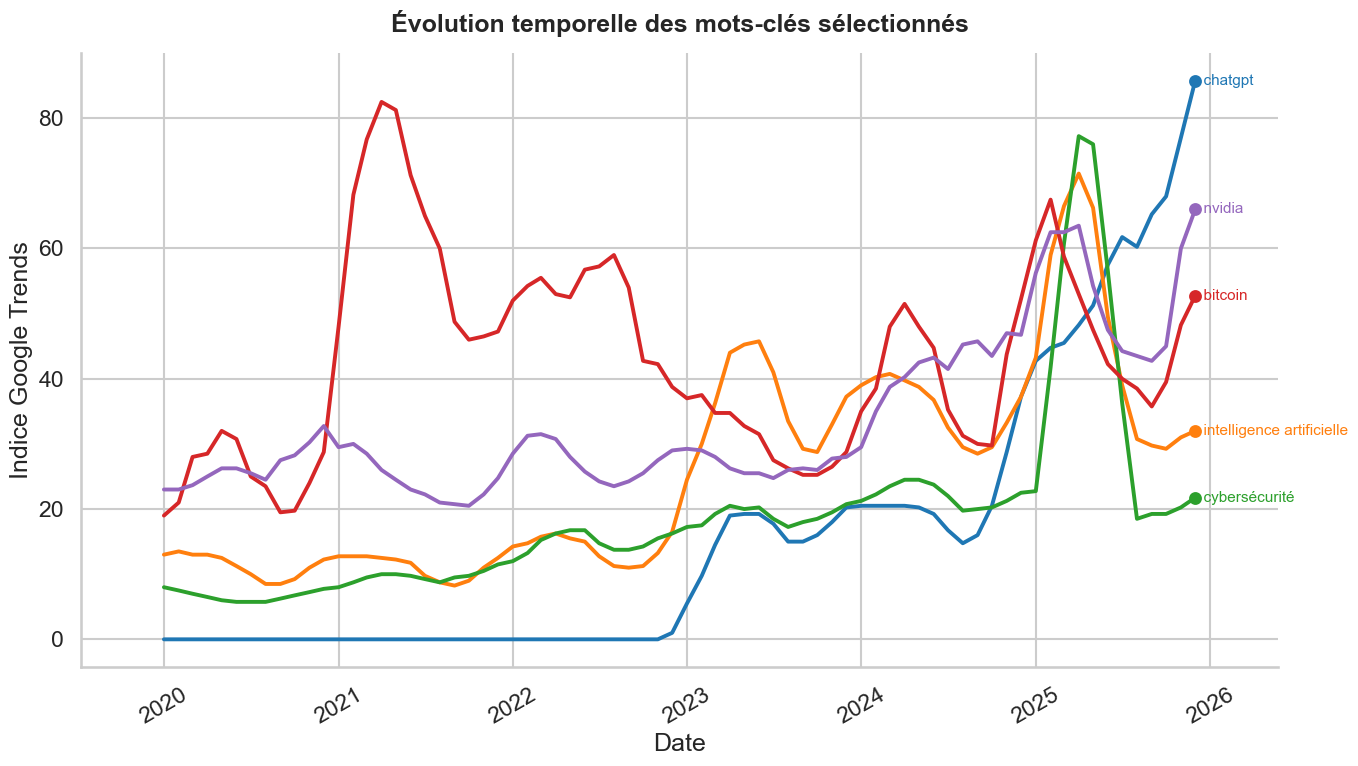

In [121]:
selection = ["chatgpt", "intelligence artificielle", "cybersécurité", "bitcoin", "nvidia"]

# On garde uniquement les mots-clés présents
selection_valides = [mot for mot in selection if mot in df_wide.columns]

# Style global
sns.set_theme(style="whitegrid", context="talk")

fig, ax = plt.subplots(figsize=(14, 8))

palette = sns.color_palette("tab10", len(selection_valides))

for i, mot in enumerate(selection_valides):
    serie = df_wide[mot].copy()

    # Lissage léger pour rendre les courbes plus lisibles
    serie_lissee = serie.rolling(window=4, min_periods=1).mean()

    ax.plot(
        df_wide.index,
        serie_lissee,
        label=mot,
        linewidth=2.8,
        color=palette[i]
    )

    # Mettre en valeur le dernier point
    ax.scatter(
        df_wide.index[-1],
        serie_lissee.iloc[-1],
        s=60,
        color=palette[i],
        zorder=3
    )

    # Ajouter le nom du mot-clé à droite
    ax.text(
        df_wide.index[-1],
        serie_lissee.iloc[-1],
        f"  {mot}",
        va="center",
        fontsize=11,
        color=palette[i]
    )

# Titres et labels
ax.set_title("Évolution temporelle des mots-clés sélectionnés", fontsize=18, weight="bold", pad=15)
ax.set_xlabel("Date")
ax.set_ylabel("Indice Google Trends")

# Un peu d'espace à droite pour les labels
ax.margins(x=0.08)

# Rotation des dates
plt.xticks(rotation=30)

# Supprimer la légende car les labels sont déjà sur les courbes
if ax.get_legend() is not None:
    ax.get_legend().remove()

# Nettoyage visuel
sns.despine()
plt.tight_layout()

# Sauvegarde
plt.savefig(
    os.path.join(FIG_DIR, "courbes_selection.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interprétation
Ce graphique met en évidence **trois dynamiques principales** entre 2020 et 2025 :

* **Forte progression récente** :
  Les mots-clés **"chatgpt"**, **"intelligence artificielle"** et **"nvidia"** connaissent une **hausse très rapide à partir de fin 2022**, en lien avec la médiatisation de l’IA générative (notamment le lancement de ChatGPT). Cela traduit un **engouement massif et récent**.

* **Tendance stable** :
  **"cybersécurité"** et **"cloud computing"** évoluent de manière **régulière et sans rupture majeure**, ce qui montre qu’il s’agit de **technologies déjà installées** et utilisées de façon continue.

* **Forte volatilité** :
  **"bitcoin"** présente des **pics importants et irréguliers**, reflétant la dépendance aux cycles du marché des cryptomonnaies.

Ces différences de comportement montrent qu’il existe **plusieurs profils de tendances**, ce qui justifie l’utilisation du **clustering** pour regrouper les mots-clés selon leur évolution.

###  Implication

Ce graphique illustre une **rupture majeure fin 2022**, marquant le passage de l’IA d’un sujet technique à un **phénomène grand public**.

###  Limite

Les données Google Trends étant **normalisées (0-100)** pour chaque mot-clé,
=> seules les **évolutions dans le temps** sont comparables,
=> pas les niveaux entre mots-clés.

## 2. Graphique 2: Top 10 des mots-clés avec l'indice moyen le plus élevé

Ce graphique présente les **10 mots-clés ayant l'indice Google Trends moyen le plus élevé** sur la période 2020-2025. 

Il ne s'agit pas directement d'un classement de popularité absolue, mais d'une mesure de **stabilité du niveau de recherche** : un mot-clé avec une moyenne élevée est proche de son maximum historique sur une grande partie de la période, ce qui traduit un intérêt **régulier et installé**.

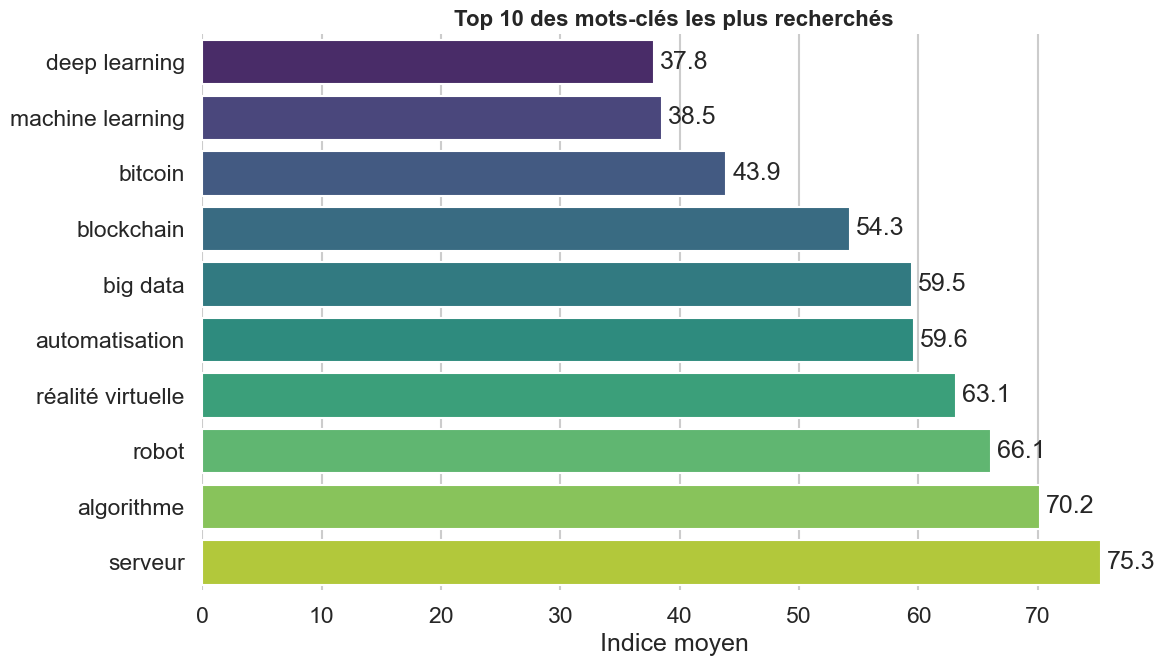

In [122]:
top10 = stats_df.sort_values("moyenne", ascending=True).tail(10)

plt.figure(figsize=(12, 7))

# Style global
sns.set_style("whitegrid")
sns.set_context("talk")

# Palette dégradée
palette = sns.color_palette("viridis", len(top10))

ax = sns.barplot(
    data=top10,
    x="moyenne",
    y="mot_cle",
    hue="mot_cle", 
    palette=palette
)

# Ajout des valeurs sur les barres
for i, v in enumerate(top10["moyenne"]):
    ax.text(v + 0.5, i, f"{v:.1f}", va="center")

# Titres et labels
plt.title("Top 10 des mots-clés les plus recherchés", fontsize=16, weight="bold")
plt.xlabel("Indice moyen")
plt.ylabel("")

# Finition esthétique
sns.despine(left=True, bottom=True)
plt.tight_layout()


# Sauvegarde
plt.savefig(os.path.join(FIG_DIR, "top10_motscles.png"), dpi=300)
plt.show()

### Interprétation 

Ce graphique met en évidence une **hiérarchie claire des mots-clés selon leur popularité moyenne** entre 2020 et 2025 :

* **Les plus recherchés** :
  *serveur*, *algorithme* et *robot* dominent, ce qui montre que les **concepts techniques fondamentaux** restent les plus présents dans les recherches.

* **Groupe intermédiaire** :
  *réalité virtuelle*, *big data*, *automatisation* et *blockchain* présentent des niveaux élevés mais légèrement inférieurs. Il s’agit de **technologies importantes mais moins centrales**.

* **Les moins recherchés du top 10** :
  *bitcoin*, *machine learning* et *deep learning* ont des moyennes plus faibles, ce qui reflète un intérêt **plus spécialisé ou plus irrégulier**.

Ainsi, on distingue **trois niveaux de popularité** :

1. sujets fondamentaux dominants
2. technologies établies intermédiaires
3. sujets plus spécifiques ou fluctuants

### Explication clé

Ce graphique repose sur une **moyenne sur 5 ans**.
Les sujets **stables dans le temps** apparaissent en tête, tandis que les sujets **récents ou irréguliers** sont moins bien classés.

### Implication

Les résultats montrent que les recherches restent majoritairement orientées vers des **bases techniques solides**, malgré l’émergence de nouvelles tendances.

### Limite

Les données Google Trends étant **normalisées (0-100)**, ce graphique reflète la **régularité de l’intérêt dans le temps** et non une comparaison directe des volumes de recherche entre mots-clés.


## 3. Graphique 3: Boxplot des dispersions par mot-clé

Ce graphique présente la **dispersion des indices Google Trends** pour les 10 mots-clés avec l'indice moyen le plus élevé. 

Un **boxplot** (boîte à moustaches) permet de visualiser d'un coup d'œil :
- La **médiane** (trait central de la boîte)
- Les **quartiles Q1 et Q3** (extrémités de la boîte → où se concentrent 50% des valeurs)
- Les **moustaches** (étendue globale hors valeurs extrêmes)
- Les **outliers** (points isolés, valeurs atypiques)

Plus la boîte est **grande**, plus le mot-clé est **volatil** (fortes variations). Plus elle est **étroite**, plus le mot-clé est **stable**.

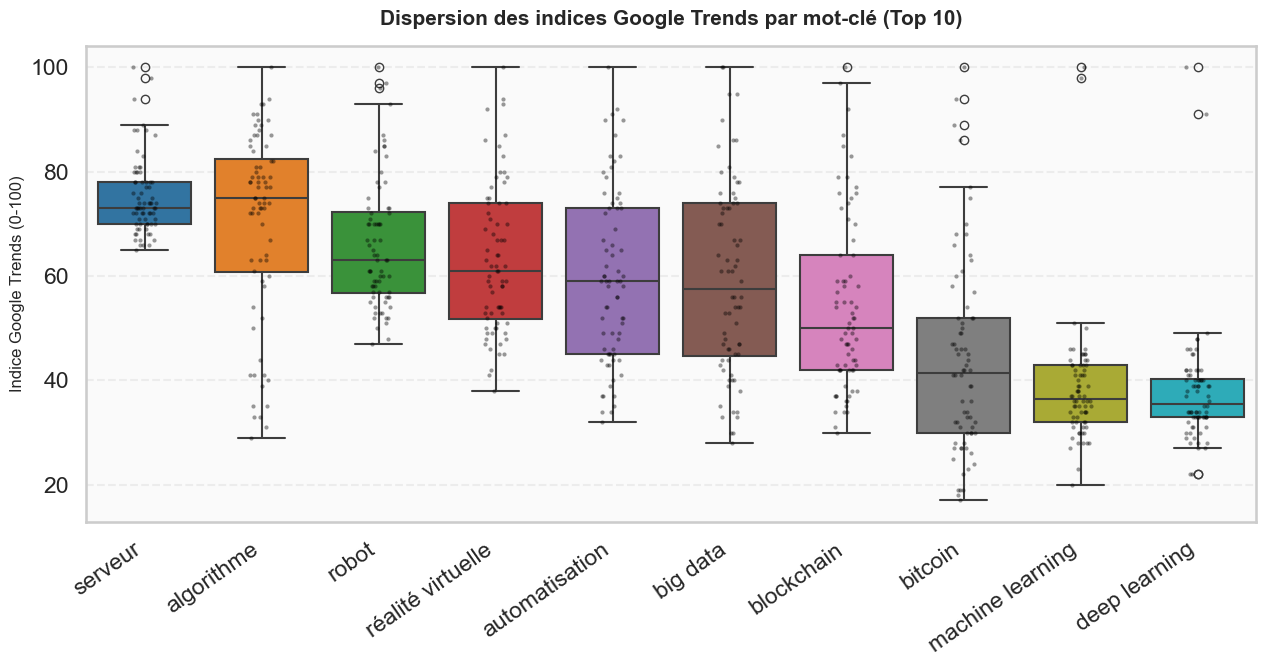

✅ Graphe 3 sauvegardé : 03_boxplot.png


In [123]:
# Graphe 3 : Boxplot des dispersions pour le top 10

# Récupérer les 10 mots-clés avec la moyenne la plus élevée
top10_mots = stats_df.sort_values("moyenne", ascending=False).head(10)["mot_cle"].tolist()

# Filtrer le df_long pour n'avoir que ces mots-clés
df_box = df_long[df_long["mot_cle"].isin(top10_mots)].copy()

# Trier l'ordre d'affichage par moyenne décroissante (pour correspondre au graphe 2)
df_box["mot_cle"] = pd.Categorical(df_box["mot_cle"], categories=top10_mots, ordered=True)

# Création du graphique
fig, ax = plt.subplots(figsize=(13, 7))

sns.boxplot(
    data=df_box,
    x="mot_cle",
    hue="mot_cle",
    y="valeur",
    ax=ax,
    palette="tab10",
    linewidth=1.5,
    fliersize=6  # taille des outliers
)

sns.stripplot(
    data=df_box,
    x="mot_cle",
    y="valeur",
    ax=ax,
    color="black",
    alpha=0.4,
    jitter=True,
    size=3
)

# Titres et labels
ax.set_title("Dispersion des indices Google Trends par mot-clé (Top 10)",
             fontsize=15, pad=15)
ax.set_xlabel("")
ax.set_ylabel("Indice Google Trends (0-100)", fontsize=12)

# Rotation des noms de mots-clés
plt.xticks(rotation=35, ha="right")

# Arrière-plan et grille
ax.set_facecolor("#FAFAFA")
ax.grid(True, axis="y", alpha=0.3, linestyle="--")

plt.tight_layout()

# Sauvegarde
plt.savefig(
    os.path.join(FIG_DIR, "03_boxplot.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print("✅ Graphe 3 sauvegardé : 03_boxplot.png")

### Interprétation 

Ce graphique met en évidence **la dispersion des recherches** pour les 10 mots-clés les plus populaires, ce qui permet de distinguer leur **stabilité ou leur volatilité** dans le temps.

* **Mots-clés très stables** :
  *serveur* et, dans une moindre mesure, *robot* présentent des boîtes étroites → les recherches sont **régulières et constantes**.

* **Dispersion intermédiaire** :
  *réalité virtuelle*, *automatisation*, *machine learning* et *deep learning* montrent une **variabilité modérée**, traduisant un intérêt globalement stable avec quelques fluctuations.

* **Mots-clés très volatils** :
  *algorithme*, *big data*, *blockchain* et surtout *bitcoin* présentent une forte dispersion → ces sujets sont **sensibles à l’actualité ou aux effets de mode**, avec des pics ponctuels.


### Explication clé

Les mots-clés les plus stables sont souvent des **sujets fondamentaux et installés**, tandis que les plus dispersés correspondent à des **thématiques en évolution ou dépendantes de contextes externes** (marché, innovation, médiatisation).

### Implication

Un même niveau moyen de popularité peut cacher des comportements très différents :

* un sujet stable → intérêt constant
* un sujet volatil → intérêt irrégulier avec pics

Cela montre l’importance de compléter l’analyse par la **dispersion** et pas seulement par la moyenne.

### Limite

Le boxplot ne prend pas en compte l’ordre temporel des données.
Il doit donc être interprété avec le graphique d’évolution pour comprendre la dynamique complète.


In [124]:
stats_df.sort_values("ecart_type")[["mot_cle", "moyenne", "ecart_type"]]

,mot_cle,moyenne,ecart_type
0,serveur,75.291667,7.417979
9,deep learning,37.847222,11.508307
13,data science,29.694444,11.927762
8,machine learning,38.527778,12.062014
2,robot,66.055556,12.437890
12,cloud computing,31.916667,12.699950
11,gpu,31.958333,13.662365
3,réalité virtuelle,63.125000,14.249228
10,nvidia,34.597222,14.950302
4,automatisation,59.611111,16.762261


## 4. Graphique 4: Distribution globale des indices Google Trends

Ce graphique présente la **distribution de l'ensemble des valeurs** d'indices Google Trends, tous mots-clés confondus, sur toute la période 2020-2025 (soit 1 440 observations au total).

Contrairement aux graphiques précédents qui comparaient les mots-clés entre eux, cet histogramme permet d'observer **comment se répartissent les niveaux de recherche globalement** : les valeurs sont-elles concentrées sur une plage particulière ? Y a-t-il beaucoup de pics (valeurs proches de 100) ou au contraire beaucoup de creux (valeurs proches de 0) ?

La **courbe KDE** (en superposition) permet de visualiser la distribution comme une densité lissée.

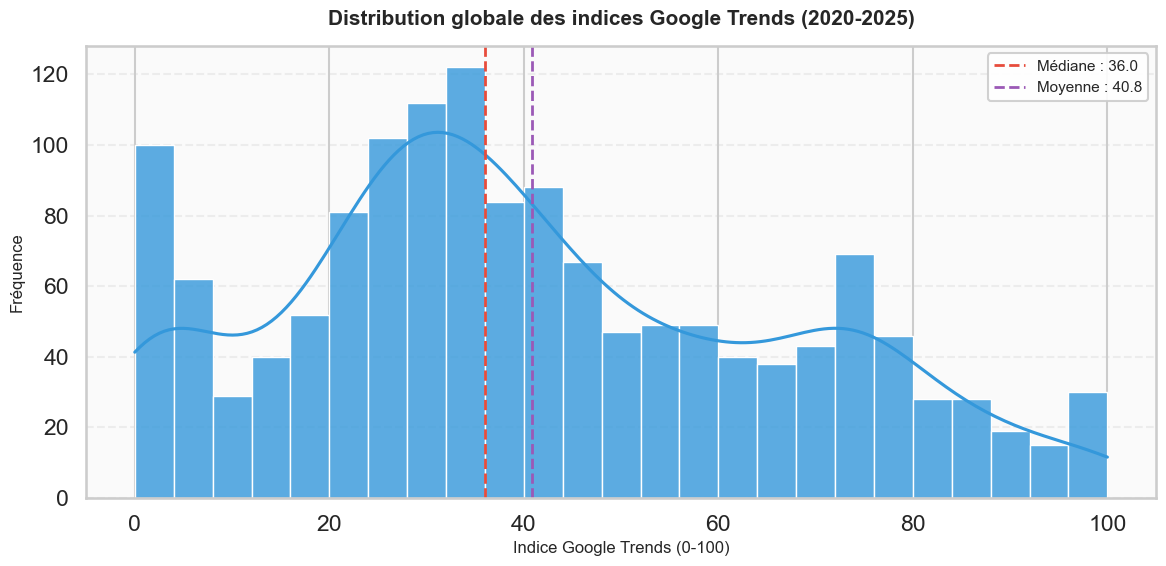

✅ Graphe 4 sauvegardé : 04_histogramme.png

📊 Statistiques globales :
   Nombre total d'observations : 1440
   Moyenne globale             : 40.84
   Médiane globale             : 36.00
   Valeur minimum              : 0
   Valeur maximum              : 100
   Valeurs à 0                 : 77
   Valeurs à 100               : 21


In [125]:
# Graphe 4 : Histogramme de la distribution globale des indices

fig, ax = plt.subplots(figsize=(12, 6))

# Histogramme avec courbe KDE
sns.histplot(
    data=df_long,
    x="valeur",
    bins=25,
    kde=True,
    color=couleurs_perso[0],
    edgecolor="white",
    linewidth=1,
    alpha=0.8,
    ax=ax
)

# Ligne verticale pour la médiane globale
mediane_globale = df_long["valeur"].median()
moyenne_globale = df_long["valeur"].mean()

ax.axvline(
    mediane_globale,
    color=couleurs_perso[2],  # corail
    linestyle="--",
    linewidth=2,
    label=f"Médiane : {mediane_globale:.1f}"
)
ax.axvline(
    moyenne_globale,
    color=couleurs_perso[4],  # lavande
    linestyle="--",
    linewidth=2,
    label=f"Moyenne : {moyenne_globale:.1f}"
)

# Titres et labels
ax.set_title("Distribution globale des indices Google Trends (2020-2025)",
             fontsize=15, pad=15)
ax.set_xlabel("Indice Google Trends (0-100)", fontsize=12)
ax.set_ylabel("Fréquence", fontsize=12)

# Légende
ax.legend(fontsize=11, loc="upper right")

# Arrière-plan et grille
ax.set_facecolor("#FAFAFA")
ax.grid(True, axis="y", alpha=0.3, linestyle="--")

plt.tight_layout()

# Sauvegarde
plt.savefig(
    os.path.join(FIG_DIR, "04_histogramme.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# Afficher quelques stats supplémentaires
print(f"✅ Graphe 4 sauvegardé : 04_histogramme.png")
print(f"\n📊 Statistiques globales :")
print(f"   Nombre total d'observations : {len(df_long)}")
print(f"   Moyenne globale             : {moyenne_globale:.2f}")
print(f"   Médiane globale             : {mediane_globale:.2f}")
print(f"   Valeur minimum              : {df_long['valeur'].min()}")
print(f"   Valeur maximum              : {df_long['valeur'].max()}")
print(f"   Valeurs à 0                 : {(df_long['valeur']==0).sum()}")
print(f"   Valeurs à 100               : {(df_long['valeur']==100).sum()}")

### Interprétation 

Ce graphique montre la **distribution globale des indices Google Trends** sur l’ensemble des mots-clés entre 2020 et 2025.

* La majorité des valeurs se situe entre **20 et 50**, ce qui indique que les recherches sont **le plus souvent à un niveau moyen**.
* Les valeurs élevées (**70 à 100**) sont **plus rares** et correspondent à des **pics d’intérêt ponctuels**.
* Les valeurs faibles (**0 à 20**) existent également, notamment pour les sujets récents ou peu recherchés.

### Explication clé

La distribution est **asymétrique à droite** :

* la **moyenne (~40)** est supérieure à la **médiane (~35)**
* cela signifie que quelques valeurs élevées (pics) **tirent la moyenne vers le haut**

Autrement dit, les pics de popularité sont **rares mais intenses**.

### Implication

Ce graphique montre que l’intérêt des internautes fonctionne par **cycles** :

* la plupart du temps → niveau modéré
* ponctuellement → fortes hausses

Il est donc important de distinguer :

* l’**intérêt de fond** (stable)
* les **pics d’attention** (événements ou tendances)

### Limite

Les données étant **normalisées pour chaque mot-clé**, cette distribution mélange des séries non directement comparables.
Elle permet d’analyser la forme globale des données, mais pas de comparer les niveaux entre mots-clés.


## 5. Graphique 5 : Matrice de corrélation entre les mots-clés

Ce graphique présente la **matrice de corrélation** des 20 mots-clés sur la période 2020-2025. 

La corrélation mesure à quel point deux séries évoluent de manière **synchronisée** :
- **Corrélation proche de +1** (couleur chaude intense) : les deux mots-clés montent et descendent ensemble.
- **Corrélation proche de 0** (couleur neutre) : leurs évolutions sont indépendantes.
- **Corrélation proche de -1** (couleur froide intense) : les deux mots-clés évoluent en sens opposé (l'un monte quand l'autre descend).

Cette visualisation est **essentielle** pour justifier l'analyse de clustering qui suit : des groupes de mots-clés fortement corrélés entre eux suggèrent l'existence de **profils temporels communs**.

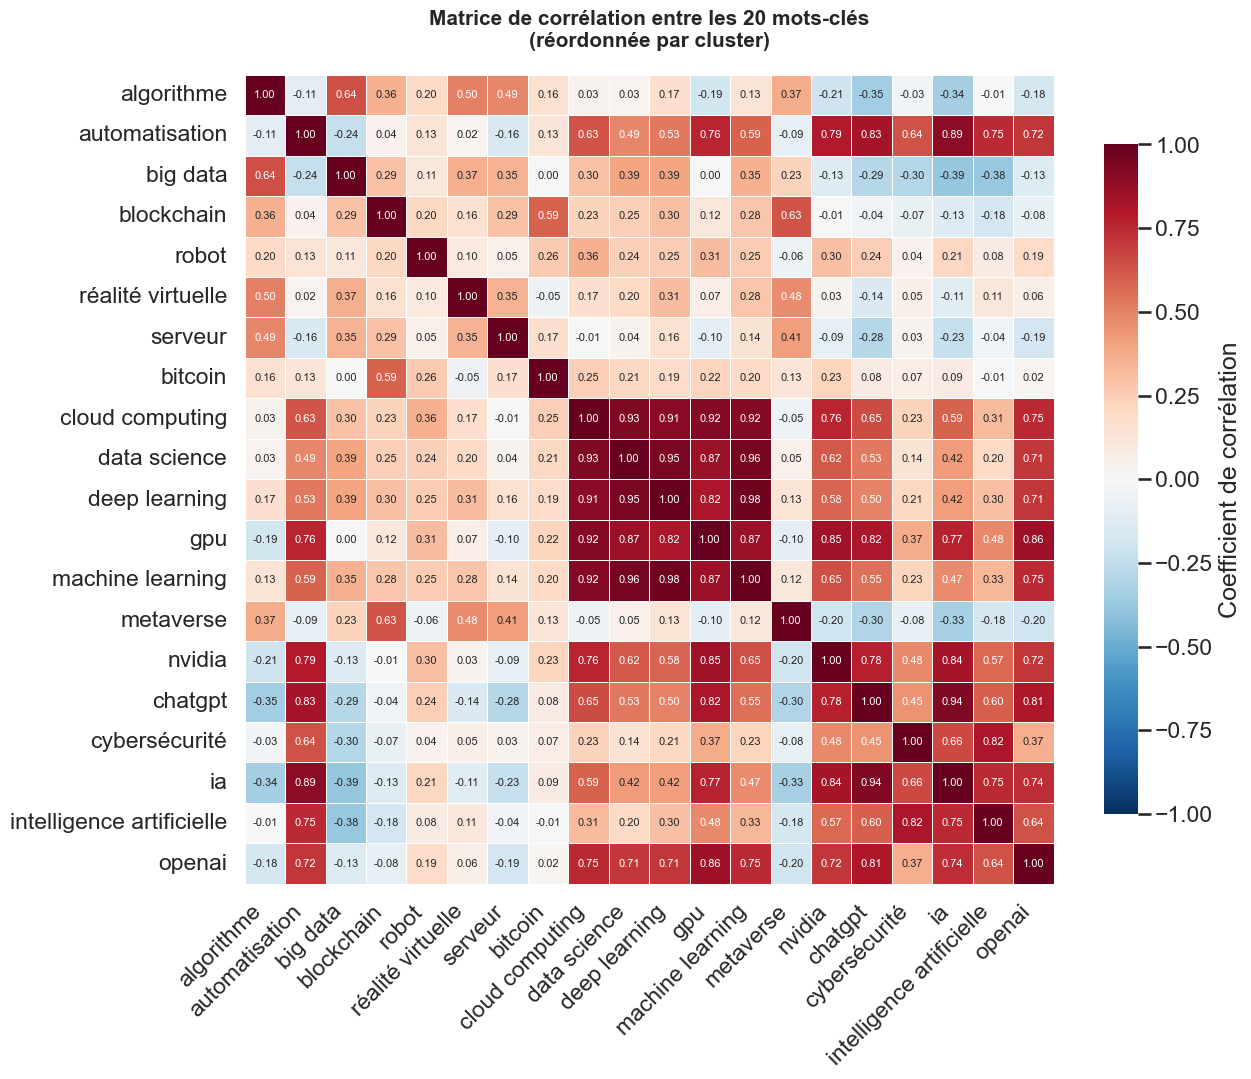

✅ Graphe 5 sauvegardé : 05_heatmap.png

🔗 Top 5 des corrélations les plus FORTES (positives) :
   deep learning                  <-> machine learning               : +0.975
   data science                   <-> machine learning               : +0.956
   data science                   <-> deep learning                  : +0.952
   chatgpt                        <-> ia                             : +0.937
   cloud computing                <-> data science                   : +0.935

🔗 Top 5 des corrélations les plus FORTES (négatives) :
   big data                       <-> ia                             : -0.387
   big data                       <-> intelligence artificielle      : -0.376
   algorithme                     <-> chatgpt                        : -0.349
   algorithme                     <-> ia                             : -0.339
   ia                             <-> metaverse                      : -0.328


In [144]:
# Graphe 5 : Heatmap de corrélation entre mots-clés

# Option : réordonner la matrice selon l'ordre des clusters pour que les groupes apparaissent
# Création d'un ordre basé sur les clusters
ordre_clusters = cluster_df.sort_values(["cluster", "mot_cle"])["mot_cle"].tolist()
corr_ordered = corr_matrix.loc[ordre_clusters, ordre_clusters]

# Création du graphique
fig, ax = plt.subplots(figsize=(13, 11))

sns.heatmap(
    corr_ordered,
    cmap="RdBu_r",          # palette divergente rouge-bleu inversée
    center=0,               # 0 au centre de la palette
    vmin=-1, vmax=1,        # bornes fixes pour bien lire
    annot=True,             # affiche les valeurs
    fmt=".2f",              # 2 décimales
    annot_kws={"size": 8},
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Coefficient de corrélation", "shrink": 0.8},
    square=True,
    ax=ax
)

# Titres
ax.set_title("Matrice de corrélation entre les 20 mots-clés\n(réordonnée par cluster)",
             fontsize=15, pad=20)
ax.set_xlabel("")
ax.set_ylabel("")

# Rotation des labels
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()

# Sauvegarde
plt.savefig(
    os.path.join(FIG_DIR, "05_heatmap.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# Afficher les corrélations les plus fortes (hors diagonale)
print("✅ Graphe 5 sauvegardé : 05_heatmap.png")
print("\n🔗 Top 5 des corrélations les plus FORTES (positives) :")

# Construction de la liste des paires uniques
corr_pairs = corr_matrix.where(pd.np.triu(pd.np.ones(corr_matrix.shape), k=1).astype(bool)) \
    if hasattr(pd, 'np') else corr_matrix.where(~corr_matrix.columns.to_series().apply(
        lambda x: corr_matrix.index.get_loc(x)).gt(
        corr_matrix.columns.to_series().apply(lambda x: corr_matrix.columns.get_loc(x))
    ))

import numpy as np
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
corr_upper = corr_matrix.where(mask).stack().reset_index()
corr_upper.columns = ["mot1", "mot2", "correlation"]

top_pos = corr_upper.nlargest(5, "correlation")
for _, row in top_pos.iterrows():
    print(f"   {row['mot1']:30s} <-> {row['mot2']:30s} : {row['correlation']:+.3f}")

print("\n🔗 Top 5 des corrélations les plus FORTES (négatives) :")
top_neg = corr_upper.nsmallest(5, "correlation")
for _, row in top_neg.iterrows():
    print(f"   {row['mot1']:30s} <-> {row['mot2']:30s} : {row['correlation']:+.3f}")

### Interprétation 

Ce graphique représente les **corrélations entre les mots-clés**, c'est-à-dire la manière dont leurs évolutions dans le temps sont liées.

* Les **zones rouges** indiquent des mots-clés qui évoluent **ensemble**
* Les **zones bleues** indiquent des évolutions **opposées**
* Les blocs visibles montrent des **groupes cohérents (clusters)**

### Résultats principaux

* Un **groupe très fortement corrélé** apparaît autour des technologies IA :
  * *deep learning ↔ machine learning : **+0.98***
  * *data science ↔ machine learning : **+0.96***
  * *data science ↔ deep learning : **+0.95***
  * *cloud computing ↔ data science : **+0.93***
  * *chatgpt ↔ ia : **+0.94***
  * *automatisation ↔ ia : **+0.90***
  
  → ces termes évoluent **de manière quasi-identique**, liés à l'essor de l'IA générative.

* Un groupe plus **stable et technique** :
  * *serveur, robot, algorithme, big data, réalité virtuelle*
  
  → corrélations plus faibles et évolutions moins synchronisées. Ce sont des termes de fond, peu sensibles aux effets de mode.

* Certains mots-clés ont des **comportements plus indépendants** :
  * *bitcoin, metaverse*
  
  → évoluent selon des logiques propres (cycles crypto pour bitcoin, bulle médiatique pour metaverse).

* On observe aussi des **corrélations négatives intéressantes** :
  * *big data ↔ intelligence artificielle : **-0.37***
  * *big data ↔ ia : **-0.38***
  * *algorithme ↔ chatgpt : **-0.35***
  
  → traduit un **remplacement progressif des anciens termes par les nouveaux**. À mesure que "IA" devient le terme grand public, "big data" et "algorithme" reculent dans le langage courant.

### Idée clé

Les mots-clés ne sont pas indépendants : ils forment des **écosystèmes**. En particulier, l'IA constitue un **bloc cohérent** où tous les termes progressent ensemble (corrélations supérieures à 0.90), tandis que les technologies installées forment un groupe plus stable et moins synchronisé.

### Implication

Cette matrice confirme que :
* le **clustering en 3 groupes est pertinent** (les blocs sont visibles sur la diagonale)
* les tendances technologiques évoluent par **familles de sujets**, pas isolément
* certains termes "anciens" (big data) sont en train d'être remplacés par des termes plus modernes (IA, machine learning)

### Limite

La corrélation mesure uniquement des **relations linéaires simultanées**. Elle ne capture pas les décalages dans le temps (par exemple si un mot-clé monte d'abord puis l'autre) ni les relations plus complexes.

## 6. Graphique 6 : Méthode du coude pour le choix du nombre de clusters

Avant de lancer un algorithme de clustering K-Means, il faut choisir le **nombre optimal de groupes `k`** à former. La **méthode du coude** (*elbow method*) est la technique la plus utilisée pour ce choix.

**Principe** :
- On teste K-Means avec différentes valeurs de k (ici de 2 à 6).
- Pour chaque k, on calcule l'**inertie** (somme des distances au carré entre chaque point et le centre de son cluster).
- Plus k augmente, plus l'inertie diminue (plus de clusters = points plus proches de leur centre).
- On cherche le **"coude"** : la valeur de k après laquelle l'inertie diminue beaucoup moins.

Ce coude représente le **meilleur compromis** entre :
- un **nombre raisonnable de clusters** (pas trop pour rester interprétable),
- et une **inertie suffisamment réduite** (pour que les clusters soient compacts).

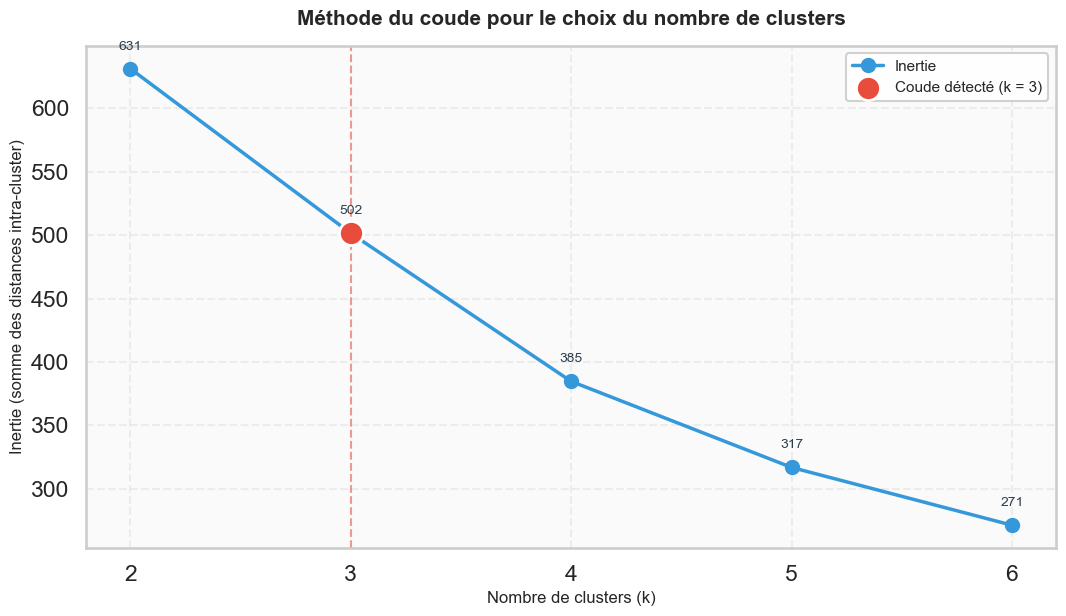

✅ Graphe 6 sauvegardé : 06_methode_coude.png

🎯 Nombre optimal de clusters détecté : k = 3

📊 Évolution de l'inertie :
   k = 2 : inertie = 631.35
   k = 3 : inertie = 501.53 (gain de 129.82)
   k = 4 : inertie = 384.69 (gain de 116.84)
   k = 5 : inertie = 316.80 (gain de 67.89)
   k = 6 : inertie = 271.23 (gain de 45.57)


In [145]:
# Graphe 6 : Méthode du coude

import numpy as np

# Calcul des variations d'inertie pour identifier le coude
inerties = elbow_df["inertie"].values
k_values = elbow_df["k"].values

# Différences successives (pente)
diffs = np.diff(inerties)
# Différences des différences (courbure)
diffs2 = np.diff(diffs)

# Le coude est le point où la courbure change le plus (accélération minimale)
k_opt_idx = np.argmin(diffs2) + 1
k_opt = k_values[k_opt_idx]
inertie_opt = inerties[k_opt_idx]

# Création du graphique
fig, ax = plt.subplots(figsize=(11, 6.5))

# Courbe principale
ax.plot(
    k_values,
    inerties,
    marker="o",
    markersize=10,
    color=couleurs_perso[0],
    linewidth=2.5,
    label="Inertie"
)

# Highlight du point optimal
ax.scatter(
    k_opt, inertie_opt,
    s=300,
    color=couleurs_perso[2],
    zorder=5,
    edgecolor="white",
    linewidth=2,
    label=f"Coude détecté (k = {k_opt})"
)

# Ligne verticale pointillée
ax.axvline(
    k_opt,
    linestyle="--",
    color=couleurs_perso[2],
    alpha=0.5,
    linewidth=1.5
)

# Annotations des valeurs d'inertie
for k, inertie in zip(k_values, inerties):
    ax.text(
        k,
        inertie + 15,
        f"{inertie:.0f}",
        ha="center",
        fontsize=10,
        color="#2C3E50"
    )

# Titres et labels
ax.set_title("Méthode du coude pour le choix du nombre de clusters",
             fontsize=15, pad=15)
ax.set_xlabel("Nombre de clusters (k)", fontsize=12)
ax.set_ylabel("Inertie (somme des distances intra-cluster)", fontsize=12)

# Ticks entiers pour k
ax.set_xticks(k_values)

# Légende
ax.legend(fontsize=11, loc="upper right")

# Arrière-plan et grille
ax.set_facecolor("#FAFAFA")
ax.grid(True, alpha=0.3, linestyle="--")

plt.tight_layout()

# Sauvegarde
plt.savefig(
    os.path.join(FIG_DIR, "06_methode_coude.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print(f"✅ Graphe 6 sauvegardé : 06_methode_coude.png")
print(f"\n🎯 Nombre optimal de clusters détecté : k = {k_opt}")
print(f"\n📊 Évolution de l'inertie :")
for i, (k, inertie) in enumerate(zip(k_values, inerties)):
    if i > 0:
        gain = inerties[i-1] - inertie
        print(f"   k = {k} : inertie = {inertie:.2f} (gain de {gain:.2f})")
    else:
        print(f"   k = {k} : inertie = {inertie:.2f}")

###  Interprétation 

Ce graphique montre l'évolution de **l'inertie du modèle K-Means** selon le nombre de clusters (k), afin de déterminer le nombre optimal de groupes.

* L'inertie **diminue fortement** entre **k=2 et k=4** (gains supérieurs à 115 points)
  → ajouter des clusters améliore nettement le modèle

* À partir de **k=5**, la baisse devient **beaucoup plus faible** (gain de 68 points seulement, soit presque moitié moins)
  → les gains deviennent limités

* Le **coude est détecté automatiquement à k=3**, correspondant au point où la courbure de la courbe change le plus brutalement.

### Idée clé

Le nombre optimal de clusters retenu pour l'analyse est **k=3**. Ce choix est à la fois :
* **statistiquement justifié** : détection automatique par la méthode du coude
* **pratiquement pertinent** : avec 20 mots-clés, 3 clusters permettent d'obtenir des groupes suffisamment fournis (5 à 8 mots-clés chacun) pour une analyse robuste et interprétable

### Implication

Ce choix méthodologique :
* évite un **choix arbitraire** de k
* garantit un **regroupement statistiquement pertinent**
* permet de distinguer trois **profils sémantiquement cohérents** : sujets installés / sujets en progression régulière / sujets IA en explosion récente

### Limite

La méthode du coude reste **partiellement subjective** — différentes méthodes de détection peuvent donner des résultats légèrement différents. Pour une analyse plus rigoureuse, on pourrait compléter par d'autres méthodes comme l'**indice de silhouette** ou le **score de Calinski-Harabasz**, qui permettraient de confirmer ou nuancer ce choix.

## Graphique  : visualisation des clusters PCA

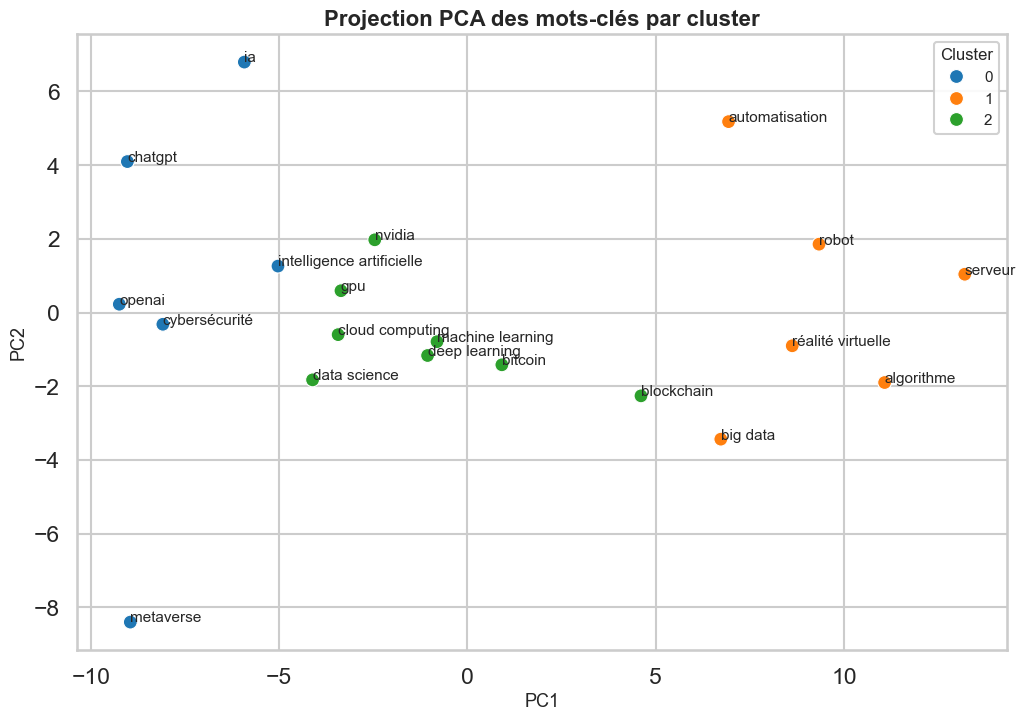

In [160]:
# 🔹 1. Données
X = df_wide.T.values   # ✅ correction clé

# 🔹 2. Standardisation
from sklearn.preprocessing import StandardScaler
X_scaled = StandardScaler().fit_transform(X)

# 🔹 3. PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 🔹 4. Clustering
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# 🔹 5. Plot
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=clusters,
    palette="tab10",
    s=100  # taille des points
)

for i, mot in enumerate(df_wide.columns):
    plt.text(
        X_pca[i,0],
        X_pca[i,1],
        mot,
        fontsize=11   # 🔥 augmente ici (test 10 → 14)
    )

plt.title("Projection PCA des mots-clés par cluster", fontsize=16)
plt.xlabel("PC1", fontsize=13)
plt.ylabel("PC2", fontsize=13)

plt.legend(title="Cluster", fontsize=11, title_fontsize=12)
plt.show()

## 7. Graphique 7: Évolution temporelle des mots-clés par cluster

Ce graphique présente les **3 clusters identifiés par K-Means**, chacun dans un sous-graphique séparé. Pour chaque cluster, les courbes des mots-clés associés sont tracées sur la période 2020-2025.

L'objectif est de **vérifier visuellement** que les mots-clés regroupés ensemble suivent bien des **dynamiques temporelles similaires**. Si c'est le cas, cela confirme la pertinence du clustering et permet d'identifier **3 profils distincts** de comportement.

Cette visualisation est **essentielle** pour :
- **Valider** la segmentation automatique produite par K-Means
- **Nommer** chaque cluster selon son profil dominant
- **Raconter une histoire** claire lors de la soutenance

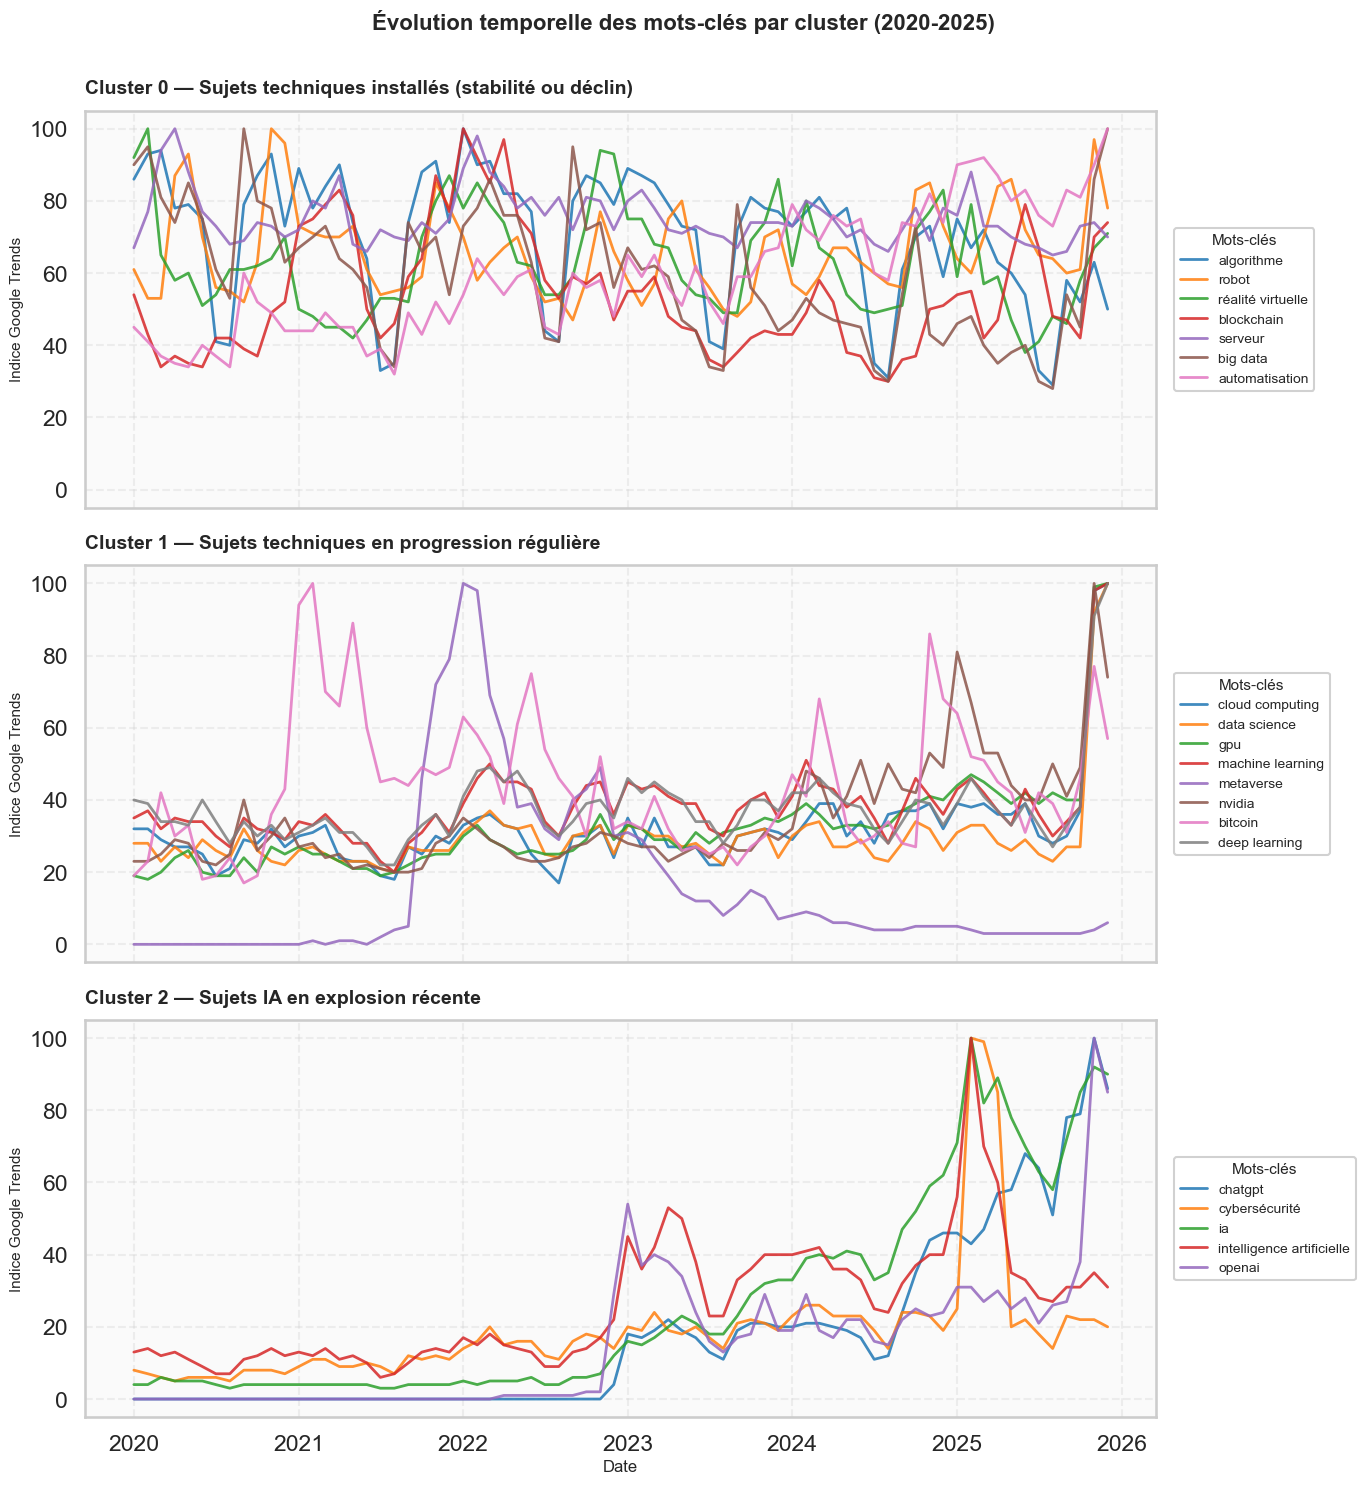

✅ Graphe 7 sauvegardé : 07_clusters_evolution.png

📦 Composition des clusters :

   Cluster 0 (7 mots-clés) :
      - algorithme
      - robot
      - réalité virtuelle
      - blockchain
      - serveur
      - big data
      - automatisation

   Cluster 1 (8 mots-clés) :
      - cloud computing
      - data science
      - gpu
      - machine learning
      - metaverse
      - nvidia
      - bitcoin
      - deep learning

   Cluster 2 (5 mots-clés) :
      - chatgpt
      - cybersécurité
      - ia
      - intelligence artificielle
      - openai


In [146]:
# Graphe 7 : Évolution des mots-clés par cluster

# Récupérer les clusters uniques
clusters_uniques = sorted(cluster_df["cluster"].unique())
n_clusters = len(clusters_uniques)

# Palette étendue pour différencier les courbes dans chaque cluster
palette_cluster = sns.color_palette("tab10", n_colors=10)

# Création d'une figure avec 3 sous-graphiques (un par cluster)
fig, axes = plt.subplots(n_clusters, 1, figsize=(14, 5 * n_clusters), sharex=True)

# Noms des profils pour chaque cluster (basés sur l'analyse précédente)
noms_clusters = {
    0: "Cluster 0 — Sujets techniques installés (stabilité ou déclin)",
    1: "Cluster 1 — Sujets techniques en progression régulière",
    2: "Cluster 2 — Sujets IA en explosion récente"
}

for idx, cluster_id in enumerate(clusters_uniques):
    ax = axes[idx]
    
    # Récupérer les mots-clés du cluster
    mots_cluster = cluster_df[cluster_df["cluster"] == cluster_id]["mot_cle"].tolist()
    
    # Tracer chaque mot-clé du cluster
    for i, mot in enumerate(mots_cluster):
        if mot in df_wide.columns:
            ax.plot(
                df_wide.index,
                df_wide[mot],
                label=mot,
                color=palette_cluster[i % len(palette_cluster)],
                linewidth=2,
                alpha=0.85
            )
    
    # Titre du sous-graphique
    ax.set_title(
        noms_clusters.get(cluster_id, f"Cluster {cluster_id}"),
        fontsize=14,
        pad=12,
        loc="left"
    )
    
    # Labels
    ax.set_ylabel("Indice Google Trends", fontsize=11)
    
    # Légende à droite du graphique
    ax.legend(
        loc="center left",
        bbox_to_anchor=(1.01, 0.5),
        fontsize=10,
        title="Mots-clés",
        title_fontsize=11,
        frameon=True
    )
    
    # Grille et arrière-plan
    ax.grid(True, alpha=0.3, linestyle="--")
    ax.set_facecolor("#FAFAFA")
    
    # Limites y cohérentes
    ax.set_ylim(-5, 105)

# Label x uniquement sur le dernier graphique
axes[-1].set_xlabel("Date", fontsize=12)

# Titre global
fig.suptitle("Évolution temporelle des mots-clés par cluster (2020-2025)",
             fontsize=16, fontweight="bold", y=0.995)

plt.tight_layout()

# Sauvegarde
plt.savefig(
    os.path.join(FIG_DIR, "07_clusters_evolution.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print("✅ Graphe 7 sauvegardé : 07_clusters_evolution.png")

# Afficher la composition des clusters
print("\n📦 Composition des clusters :")
for cluster_id in clusters_uniques:
    mots = cluster_df[cluster_df["cluster"] == cluster_id]["mot_cle"].tolist()
    print(f"\n   Cluster {cluster_id} ({len(mots)} mots-clés) :")
    for mot in mots:
        print(f"      - {mot}")

### Interprétation 

Ce graphique présente l'évolution des mots-clés regroupés en **3 clusters**, chacun correspondant à un type de dynamique différente dans le temps.

### Cluster 0 — Sujets techniques installés (stabilité ou déclin)

**Mots-clés** : algorithme, automatisation, big data, blockchain, réalité virtuelle, serveur, robot

* Niveaux **élevés et relativement réguliers** dans le temps
* Fluctuations modérées, sans pics majeurs ni chutes brutales
* Certains mots-clés (*big data*, *algorithme*, *réalité virtuelle*) affichent une **légère tendance à la baisse** sur la période récente

**Idée clé :**
Ce cluster rassemble des **technologies matures** et **installées** dans le paysage numérique, dont l'intérêt reste structurel mais qui commencent à être remplacées dans le langage courant par des termes plus modernes.

### Cluster 1 — Sujets techniques en progression régulière

**Mots-clés** : bitcoin, nvidia, metaverse, gpu, machine learning, deep learning, cloud computing, data science

* Progression **globale positive** sur la période, sans rupture brutale
* Quelques pics ponctuels (notamment *bitcoin* et *metaverse* liés aux cycles de l'actualité)
* Niveaux intermédiaires, en hausse progressive

**Idée clé :**
Ce cluster regroupe des **technologies en croissance régulière**, liées à la chaîne de valeur de l'IA (nvidia, gpu) ou aux métiers de la data (machine learning, deep learning, data science). Leur dynamique est soutenue mais moins spectaculaire que celle du cluster 2.

### Cluster 2 — Sujets IA en explosion récente

**Mots-clés** : cybersécurité, intelligence artificielle, ia, chatgpt, openai

* Courbes **très plates au début** (2020-2022), souvent proches de zéro
* **Explosion brutale à partir de fin 2022**, coïncidant avec le lancement public de ChatGPT
* Atteinte rapide des pics historiques (valeurs proches de 100)

**Idée clé :**
Ce cluster incarne la **rupture de l'IA générative**. Les cinq mots-clés ont basculé simultanément dans l'attention du grand public après novembre 2022, reflétant un **phénomène culturel majeur** plutôt qu'une simple tendance technique.

### Résultats principaux

* Le clustering révèle **trois dynamiques fondamentalement différentes** :
  - **Stabilité / déclin** pour les termes installés
  - **Progression régulière** pour les sujets techniques de la data
  - **Rupture explosive** pour l'IA grand public

* Les 20 mots-clés se répartissent de manière **équilibrée** : 7, 8 et 5 mots-clés par cluster, ce qui assure une analyse robuste.

### Idée clé

Ces trois profils ne sont pas de simples groupes statistiques : ils racontent une **histoire cohérente du paysage numérique 2020-2025**, marquée par :
1. Le **vieillissement** de certains termes techniques
2. La **stabilité** des métiers de la data
3. L'**émergence fulgurante** de l'IA générative grand public

### Implication

Ce regroupement automatique confirme que :
* les tendances de recherche évoluent par **familles de sujets**
* le public distingue **intuitivement** les sujets installés, en progression et en rupture
* une stratégie éditoriale ou marketing doit **s'adapter au cluster** plutôt qu'au mot-clé individuel

### Limite

Le clustering K-Means est **sensible à l'initialisation** et à la normalisation. Ici, l'usage de `random_state=42` garantit la reproductibilité, et `StandardScaler` assure la comparabilité des formes de courbes. Un corpus plus vaste (50+ mots-clés) pourrait révéler des sous-catégories plus fines (ex : séparation entre IA générative et IA embarquée).

## Enrichir l'interprétation avec les statistiques


In [129]:
stats_df.sort_values("ecart_type", ascending=False).head(10)
stats_df.sort_values("variation_absolue", ascending=False).head(10)
stats_df.sort_values("variation_relative", ascending=False).head(10)

,mot_cle,moyenne,mediane,minimum,maximum,ecart_type,amplitude,moyenne_debut,moyenne_fin,variation_absolue,variation_relative,rang_popularite,rang_volatilite
14,ia,26.416667,13.5,3,100,28.439583,97,4.500,76.000,71.500,15.888889,15.0,1.0
16,cybersécurité,18.847222,16.5,5,100,17.111613,95,6.125,20.125,14.000,2.285714,17.0,9.0
15,intelligence artificielle,25.944444,22.5,6,100,17.202922,94,10.750,31.375,20.625,1.918605,16.0,8.0
11,gpu,31.958333,29.0,18,100,13.662365,82,20.625,55.125,34.500,1.672727,12.0,14.0
10,nvidia,34.597222,28.5,20,100,14.950302,80,24.750,54.750,30.000,1.212121,11.0,12.0
4,automatisation,59.611111,59.0,32,100,16.762261,68,37.875,83.250,45.375,1.198020,5.0,11.0
12,cloud computing,31.916667,30.0,17,100,12.699950,83,26.500,49.750,23.250,0.877358,13.0,15.0
7,bitcoin,43.902778,41.5,17,100,18.797782,83,26.000,45.625,19.625,0.754808,8.0,5.0
13,data science,29.694444,27.0,20,100,11.927762,80,26.125,43.625,17.500,0.669856,14.0,18.0
8,machine learning,38.527778,36.5,20,100,12.062014,80,33.000,51.500,18.500,0.560606,9.0,17.0


### Analyse complémentaire : volatilité et dynamique des mots-clés

Cette analyse statistique permet de mieux comprendre les **différences de comportement** entre les mots-clés.

### Volatilité (écart-type)

* Les mots-clés les plus volatils sont :

  * *ia* (~29.17)
  * *bitcoin* (~18.25)
  * *intelligence artificielle* (~17)
  * *cybersécurité* (~16.5)

→ Cela traduit de **fortes variations dans le temps**, souvent liées à l’actualité ou à des effets de mode.

* À l’inverse :

  * *data science*, *machine learning* → plus stables

→ évolution plus régulière

### Variation absolue (amplitude)

* Plus fortes amplitudes :

  * *ia* (97)
  * *cybersécurité* (96)
  * *intelligence artificielle* (94)

→ ces mots-clés ont connu une **forte transformation**, passant de niveaux faibles à des pics élevés

### Analyse globale

Deux profils se distinguent :

* **Mots-clés très dynamiques et instables** → IA, cybersécurité, bitcoin
* **Mots-clés plus stables** → machine learning, data science, cloud

### Lien avec les clusters

* **Cluster IA (explosif)** → forte volatilité + fortes amplitudes
* **Cluster croissance** → volatilité modérée
* **Cluster stable** → faible variation

### Conclusion

Les technologies récentes sont **plus instables mais en forte croissance**,
tandis que les technologies plus anciennes sont **plus stables et installées**.

→ Cela illustre le **cycle de vie des technologies** : émergence → croissance → stabilisation.


In [130]:
print(stats_df.columns)

Index(['mot_cle', 'moyenne', 'mediane', 'minimum', 'maximum', 'ecart_type',
       'amplitude', 'moyenne_debut', 'moyenne_fin', 'variation_absolue',
       'variation_relative', 'rang_popularite', 'rang_volatilite'],
      dtype='object')


## 8. Graphique 8 : progression récente des mots-clés

Afin d’enrichir l’analyse, nous nous intéressons ici à la dynamique récente des mots-clés.  
Contrairement aux analyses précédentes qui portaient sur les tendances globales ou les regroupements (clustering), ce graphique met en évidence les sujets ayant connu la plus forte progression sur la période étudiée.

Pour cela, nous utilisons la variable *variation_absolue*, qui mesure la différence entre le niveau moyen en début et en fin de période. Cette approche permet d’identifier les technologies émergentes ou en forte croissance récente.

Le graphique ci-dessous présente les 5 mots-clés ayant enregistré la plus forte progression.

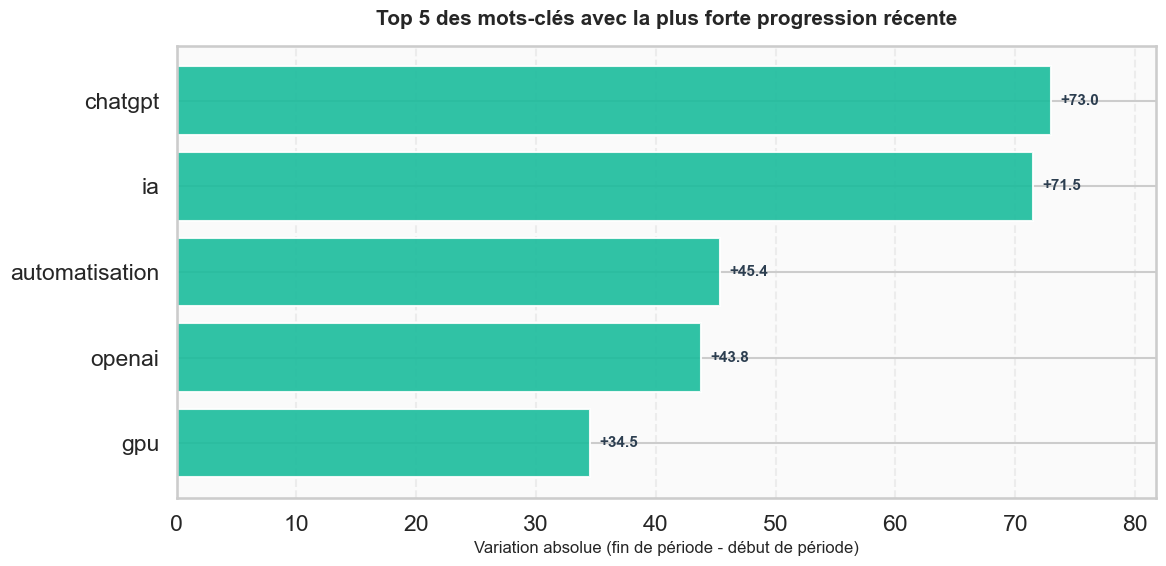

✅ Graphe 8 sauvegardé : 08_progression_recente.png

📈 Top 5 des plus fortes progressions absolues :
   chatgpt                        : +73.0 points
   ia                             : +71.5 points
   automatisation                 : +45.4 points
   openai                         : +43.8 points
   gpu                            : +34.5 points


In [149]:
# Graphe 8 : Mots-clés avec la plus forte progression récente

top_progression = stats_df.sort_values("variation_absolue", ascending=False).head(5)

fig, ax = plt.subplots(figsize=(12, 6))

# Barplot horizontal
bars = ax.barh(
    top_progression["mot_cle"][::-1],
    top_progression["variation_absolue"][::-1],
    color=couleurs_perso[1],
    edgecolor="white",
    linewidth=1.5,
    alpha=0.9
)

# Ajouter les valeurs sur chaque barre
for bar, val in zip(bars, top_progression["variation_absolue"][::-1]):
    ax.text(
        val + 0.8,
        bar.get_y() + bar.get_height() / 2,
        f"+{val:.1f}",
        va="center",
        fontsize=11,
        color="#2C3E50",
        fontweight="bold"
    )

# Titres et labels
ax.set_title("Top 5 des mots-clés avec la plus forte progression récente",
             fontsize=15, pad=15)
ax.set_xlabel("Variation absolue (fin de période - début de période)", fontsize=12)
ax.set_ylabel("")

# Limites pour laisser de la place aux labels
ax.set_xlim(0, top_progression["variation_absolue"].max() * 1.12)

# Arrière-plan et grille
ax.set_facecolor("#FAFAFA")
ax.grid(True, axis="x", alpha=0.3, linestyle="--")

plt.tight_layout()

# Sauvegarde
plt.savefig(
    os.path.join(FIG_DIR, "08_progression_recente.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print("✅ Graphe 8 sauvegardé : 08_progression_recente.png")
print("\n📈 Top 5 des plus fortes progressions absolues :")
for _, row in top_progression.iterrows():
    print(f"   {row['mot_cle']:30s} : +{row['variation_absolue']:.1f} points")

### Interprétation

Ce graphique présente les mots-clés ayant connu la **plus forte progression récente** de leur intérêt.

### Résultats principaux

* Les mots-clés les plus en hausse sont :

  * *chatgpt*
  * *ia*
  * *openai*
  * *gpu*
  * *automatisation*

* Les deux premiers (*chatgpt* et *ia*) dominent largement
  → progression beaucoup plus forte que les autres

### Idée clé

Les plus fortes progressions concernent **l’écosystème de l’intelligence artificielle**.

→ Cela confirme une **dynamique récente très forte** autour de ces technologies.

### Interprétation

* Ces mots-clés ne sont pas forcément les plus recherchés en moyenne
* Mais ce sont ceux qui **gagnent le plus d’intérêt actuellement**

→ ils représentent les **tendances émergentes**

### Conclusion

L’IA (chatgpt, ia, openai) est le principal moteur de croissance,
accompagnée par des technologies liées comme les GPU.

→ forte phase d’adoption récente

### Limite

Cette analyse mesure une **variation récente uniquement** :

* elle ne reflète pas la popularité globale
* elle dépend fortement de la période étudiée


# Conclusion générale

## Synthèse du projet

Ce projet a permis d'analyser l'évolution des recherches Google sur **20 mots-clés liés à l'intelligence artificielle et aux technologies** en France, entre **2020 et 2025**. L'approche combinée (collecte automatisée, nettoyage, analyse statistique, visualisation et clustering) a fourni une lecture complète et structurée des dynamiques observées.

## Principaux résultats

**1. Trois profils distincts de mots-clés ont été identifiés grâce au clustering K-Means :**

| Cluster | Profil | Exemples |
|---------|--------|----------|
| **Cluster 0** | Sujets techniques installés (stabilité ou déclin) | serveur, algorithme, robot, big data |
| **Cluster 1** | Sujets techniques en progression régulière | machine learning, cloud computing, nvidia, data science |
| **Cluster 2** | Sujets IA en explosion récente | chatgpt, ia, intelligence artificielle, openai |

**2. Une rupture nette autour de novembre 2022** coïncide avec le lancement public de ChatGPT, marquant un basculement culturel majeur dans l'attention portée à l'IA générative.

**3. Un remplacement lexical est visible dans les données** : le terme "big data", autrefois dominant, est progressivement remplacé par "intelligence artificielle" (corrélation négative de -0.38).

**4. Les corrélations entre mots-clés IA sont très fortes** (>0.90 pour machine learning/deep learning/data science), confirmant qu'ils forment un écosystème cohérent plutôt que des sujets isolés.

## Apports du projet

Ce travail a permis de :
- **Mobiliser l'ensemble des notions du cours** : manipulation de DataFrames, boucles, fonctions, visualisation avec matplotlib et seaborn
- **Expérimenter une chaîne complète de data science** : collecte via API (Pytrends), nettoyage, structuration, analyse statistique, visualisation et machine learning non supervisé
- **Développer un regard critique** sur les limites méthodologiques des données, notamment la nature relative des indices Google Trends
- **Travailler en binôme** avec une répartition claire des tâches (pipeline technique vs analyse visuelle)

## Limites de l'étude

Plusieurs limites doivent être soulignées pour garder un recul critique sur les résultats :

* **Nature relative des données** : les indices Google Trends sont normalisés séparément pour chaque mot-clé, rendant impossible la comparaison directe des niveaux absolus
* **Dépendance au choix des mots-clés** : la liste retenue (20 termes) oriente nécessairement l'analyse, d'autres choix auraient pu donner des clusters différents
* **Granularité mensuelle** : ne capture pas les variations fines (événements hebdomadaires)
* **Pytrends non officielle** : la reproductibilité exacte n'est pas garantie, Google pouvant ajuster son API
* **Portée géographique limitée** : les résultats concernent uniquement la France, et pourraient différer dans d'autres zones linguistiques ou culturelles

## Ouvertures et perspectives

Ce projet ouvre plusieurs pistes pour des travaux futurs :

* **Intégrer des modèles prédictifs** (ARIMA, Prophet) pour anticiper la popularité future des sujets
* **Croiser avec d'autres sources de données** : réseaux sociaux (X/Twitter), Wikipédia (page views), bases de publications scientifiques
* **Étendre le périmètre géographique** pour comparer les dynamiques entre pays
* **Affiner la granularité temporelle** (hebdomadaire ou journalière) pour détecter des événements plus ponctuels
* **Explorer des techniques de clustering plus avancées** (hiérarchique, DBSCAN) pour valider la robustesse du découpage

Ce projet illustre parfaitement **la puissance des données publiques numériques** pour comprendre les dynamiques sociétales. Au-delà de l'analyse technique, il révèle une histoire cohérente : **celle d'une révolution culturelle portée par l'IA générative**, qui redessine en temps réel le paysage numérique et les préoccupations du grand public.

L'approche adoptée — descriptive, statistique et analytique — démontre qu'il est possible d'extraire des insights riches et interprétables à partir de données simples, à condition de **rester rigoureux dans la méthode** et **critique dans l'interprétation**.